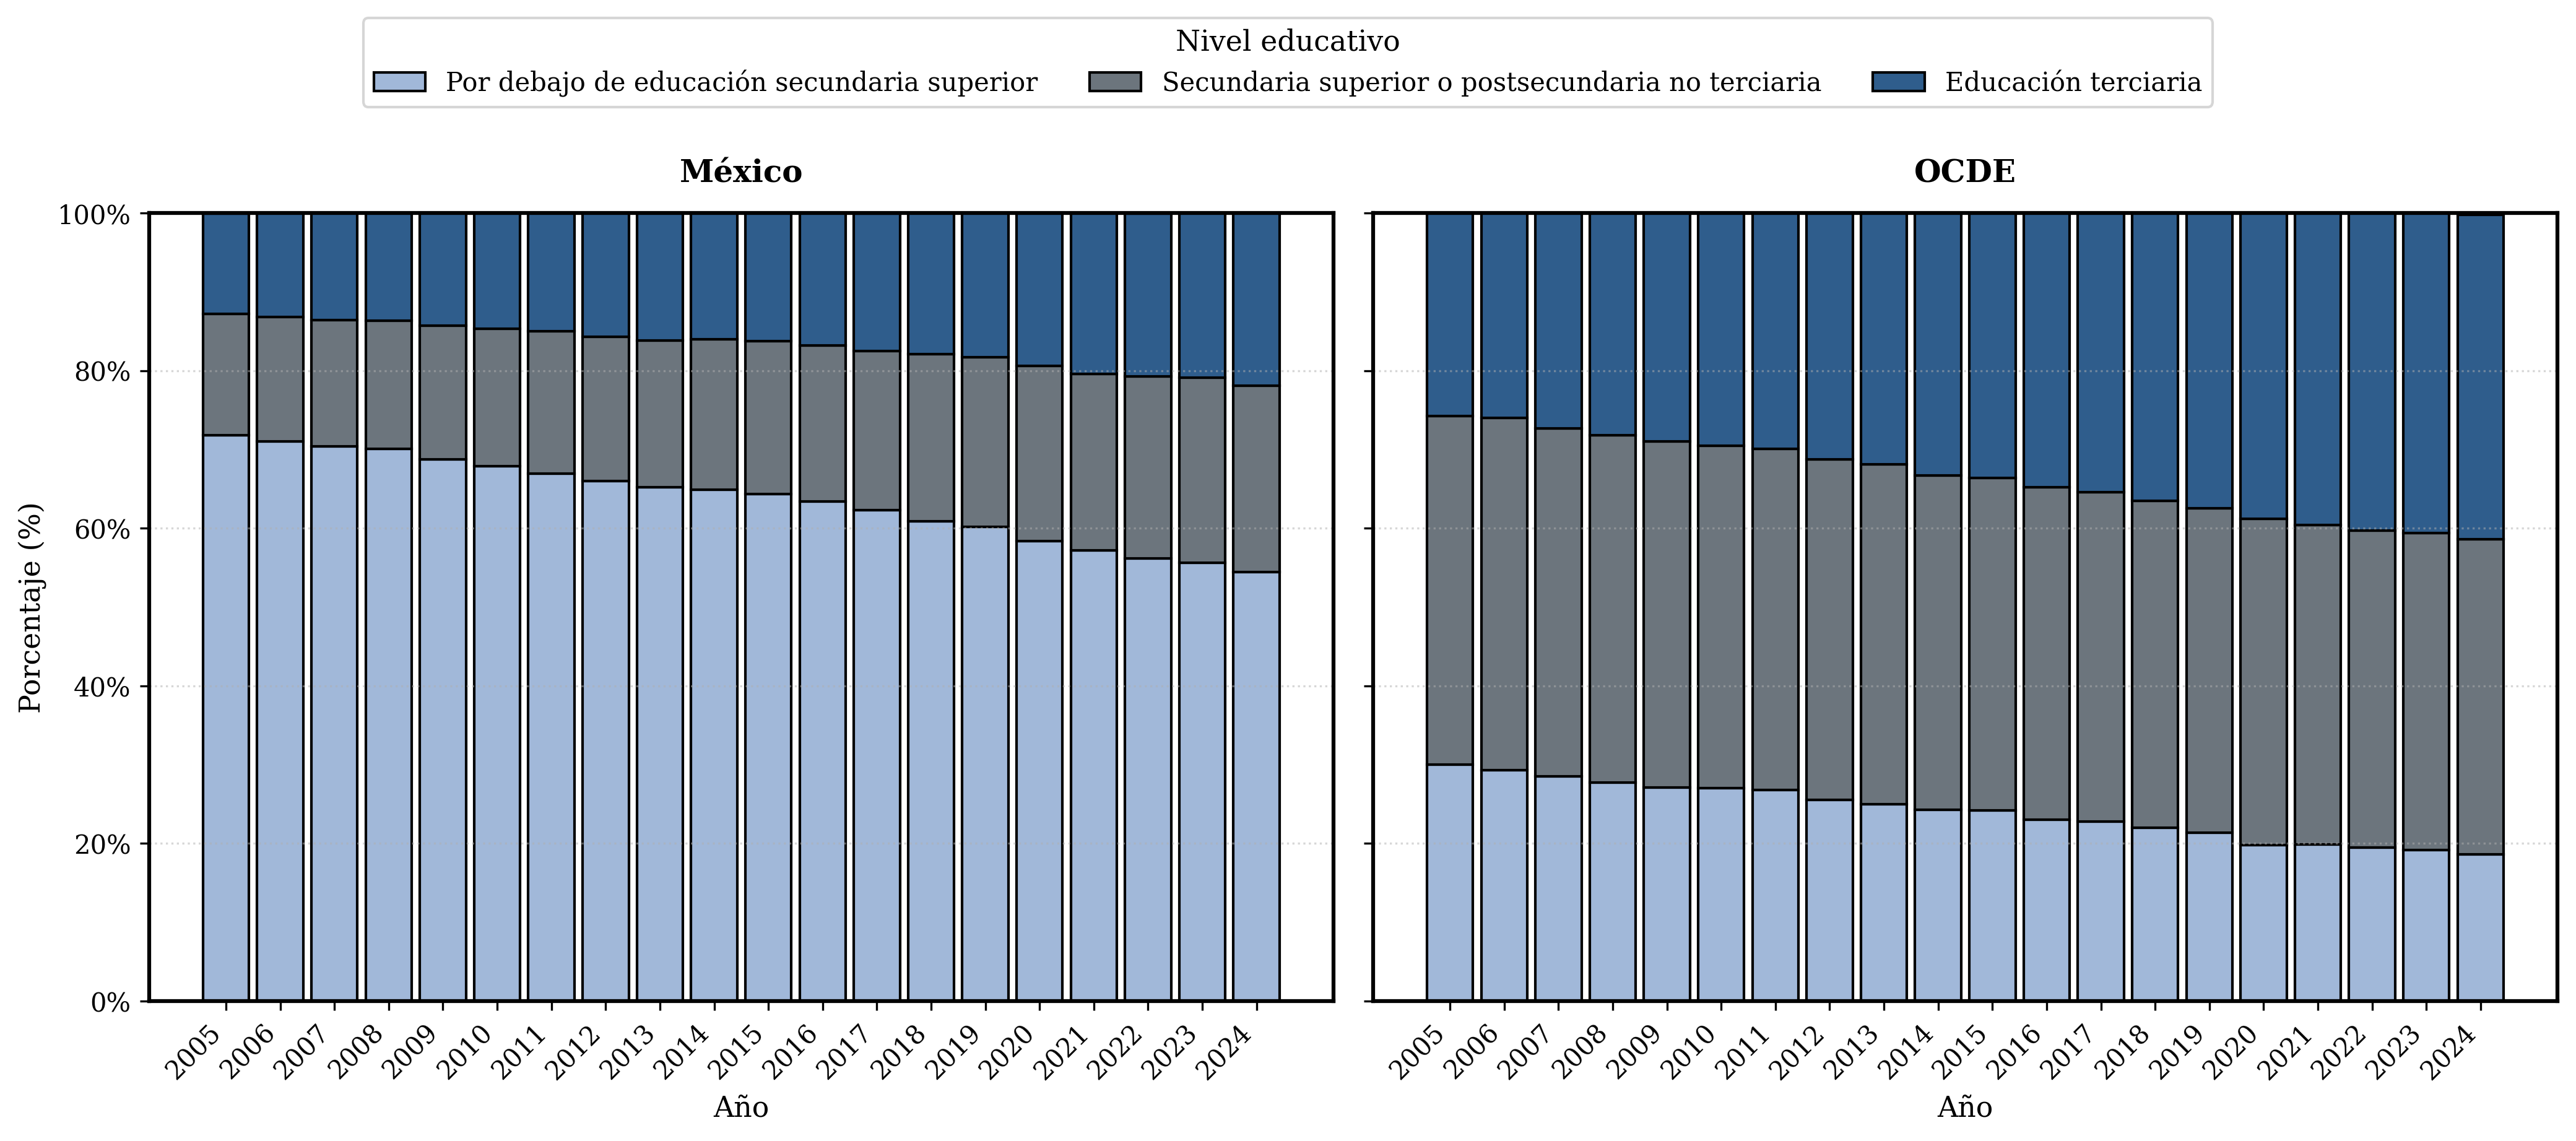

In [37]:
# =====================================================
# FIGURA 1.1 - Evolución del nivel educativo en México y la OCDE (2005-2024)
# =====================================================
import os
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# NÚMERO DE FIGURA
# =====================================================
FIG_NUM = '1.1'

# =====================================================
# ESTILO UNIFICADO DE TESIS
# =====================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# =====================================================
# DATOS
# =====================================================
years = list(range(2005, 2025))

# México
mex_below = [71.8, 71.0, 70.4, 70.1, 68.7, 67.9, 66.9, 66.0, 65.2, 64.9,
             64.3, 63.4, 62.3, 60.9, 60.2, 58.4, 57.2, 56.2, 55.6, 54.4]

mex_upper = [15.4, 15.8, 16.0, 16.2, 17.0, 17.4, 18.1, 18.3, 18.6, 19.1,
             19.4, 19.8, 20.2, 21.2, 21.5, 22.2, 22.4, 23.1, 23.5, 23.7]

mex_tertiary = [12.7, 13.3, 13.6, 13.7, 14.3, 14.7, 15.0, 15.7, 16.2, 16.0,
                16.3, 16.8, 17.4, 18.0, 18.3, 19.4, 20.5, 20.6, 21.0, 21.9]

# OCDE
oecd_below = [30.0, 29.3, 28.5, 27.7, 27.1, 27.0, 26.8, 25.5, 25.0, 24.3,
              24.2, 23.0, 22.8, 22.0, 21.4, 19.8, 19.9, 19.5, 19.2, 18.6]

oecd_upper = [44.2, 44.7, 44.2, 44.1, 43.9, 43.5, 43.3, 43.2, 43.1, 42.4,
              42.2, 42.2, 41.8, 41.5, 41.1, 41.4, 40.5, 40.2, 40.2, 40.0]

oecd_tertiary = [26.3, 26.5, 27.6, 28.6, 29.3, 29.9, 30.4, 31.8, 32.3, 33.6,
                 34.0, 35.3, 35.8, 36.9, 37.9, 39.2, 40.0, 40.7, 41.0, 41.2]

# =====================================================
# CONFIGURACIÓN DE LA FIGURA (dos paneles)
# =====================================================
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 6),
    sharey=True
)

colors = ['#A1B8D9', '#6C757D', '#2F5D8C']
bar_width = 0.85

# =====================================================
# PANEL: MÉXICO
# =====================================================
ax1.bar(years, mex_below,
        color=colors[0],
        edgecolor='black',
        width=bar_width,
        label='Por debajo de educación secundaria superior')

ax1.bar(years, mex_upper,
        bottom=mex_below,
        color=colors[1],
        edgecolor='black',
        width=bar_width,
        label='Secundaria superior o postsecundaria no terciaria')

ax1.bar(years, mex_tertiary,
        bottom=np.array(mex_below)+np.array(mex_upper),
        color=colors[2],
        edgecolor='black',
        width=bar_width,
        label='Educación terciaria')

ax1.set_title('México', fontsize=12, fontweight='bold', pad=12)

# =====================================================
# PANEL: OCDE
# =====================================================
ax2.bar(years, oecd_below,
        color=colors[0],
        edgecolor='black',
        width=bar_width,
        label='Por debajo de educación secundaria superior')

ax2.bar(years, oecd_upper,
        bottom=oecd_below,
        color=colors[1],
        edgecolor='black',
        width=bar_width,
        label='Secundaria superior o postsecundaria no terciaria')

ax2.bar(years, oecd_tertiary,
        bottom=np.array(oecd_below)+np.array(oecd_upper),
        color=colors[2],
        edgecolor='black',
        width=bar_width,
        label='Educación terciaria')

ax2.set_title('OCDE', fontsize=12, fontweight='bold', pad=12)

# =====================================================
# FORMATO DE EJES Y REJILLA
# =====================================================
ax1.set_ylim(0, 100)
ax1.set_ylabel('Porcentaje (%)')

ax1.set_yticks(np.arange(0, 101, 20))
ax1.set_yticklabels([f'{i}%' for i in range(0, 101, 20)])

for ax in (ax1, ax2):
    ax.set_xlabel('Año')
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=45, ha='right')
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

# =====================================================
# LEYENDA (FUERA DEL GRÁFICO, ARRIBA CENTRADA)
# =====================================================
handles, labels = ax1.get_legend_handles_labels()
# Tomamos solo las etiquetas únicas (en ambos paneles son iguales)
fig.legend(
    handles[:3],  # Los tres primeros (los de México) son idénticos a los de OCDE
    labels[:3],
    title='Nivel educativo',
    ncol=3,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.03),
    frameon=True
)

# Ajuste para dejar espacio arriba
fig.tight_layout(rect=[0, 0, 1, 0.92])

# =====================================================
# GUARDADO
# =====================================================
output_dir = "outputs/figures"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(output_dir, f"Figura_{FIG_NUM}.pdf"),
    bbox_inches="tight"
)
plt.savefig(
    os.path.join(output_dir, f"Figura_{FIG_NUM}.svg"),
    bbox_inches="tight"
)

plt.show()

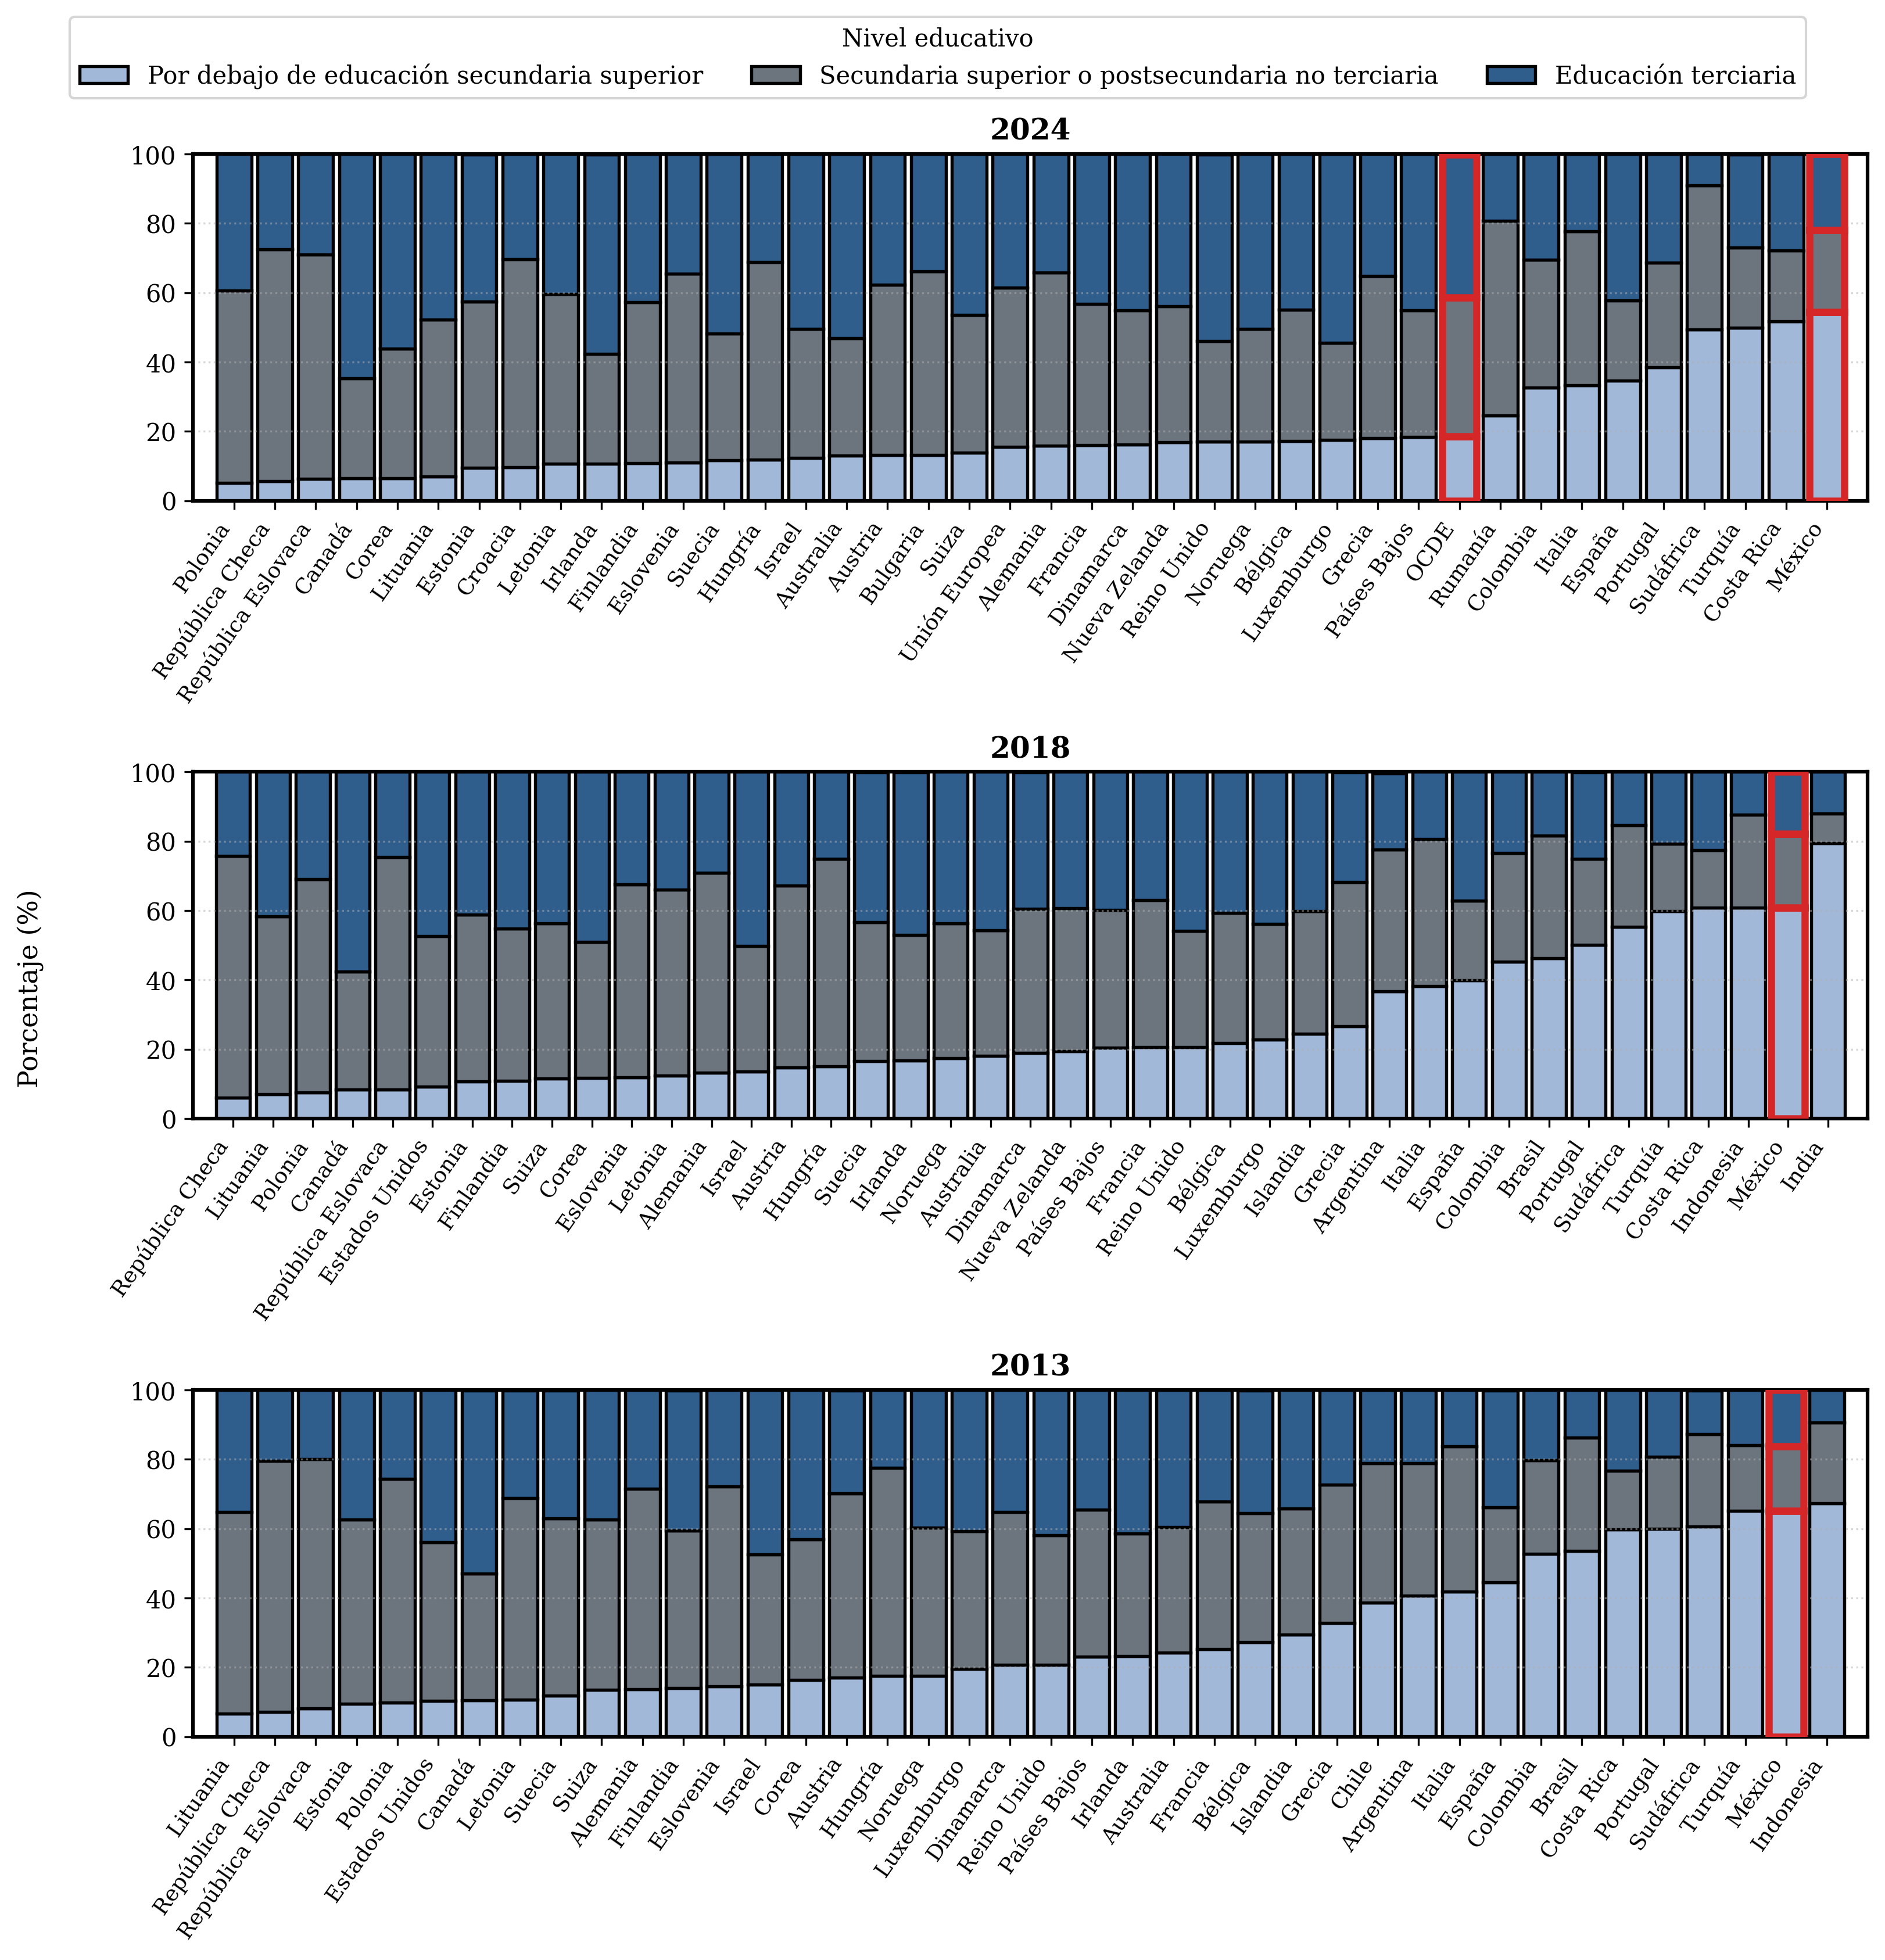

In [35]:
# =====================================================
# FIGURA 1.2 - Distribución del nivel educativo por países (2013, 2018, 2024)
# =====================================================
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =====================================================
# FIGURE NUMBER
# =====================================================
FIG_NUM = '1.2'

# =====================================================
# UNIFIED ACADEMIC STYLE
# =====================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# =====================================================
# DICCIONARIO DE TRADUCCIÓN DE PAÍSES
# =====================================================
translation = {
    'Australia': 'Australia',
    'Austria': 'Austria',
    'Belgium': 'Bélgica',
    'Canada': 'Canadá',
    'Colombia': 'Colombia',
    'Costa Rica': 'Costa Rica',
    'Czechia': 'República Checa',
    'Denmark': 'Dinamarca',
    'Estonia': 'Estonia',
    'Finland': 'Finlandia',
    'France': 'Francia',
    'Germany': 'Alemania',
    'Greece': 'Grecia',
    'Hungary': 'Hungría',
    'Ireland': 'Irlanda',
    'Israel': 'Israel',
    'Italy': 'Italia',
    'Korea': 'Corea',
    'Latvia': 'Letonia',
    'Lithuania': 'Lituania',
    'Luxembourg': 'Luxemburgo',
    'Mexico': 'México',
    'Netherlands': 'Países Bajos',
    'New Zealand': 'Nueva Zelanda',
    'Norway': 'Noruega',
    'Poland': 'Polonia',
    'Portugal': 'Portugal',
    'Slovak Republic': 'República Eslovaca',
    'Slovenia': 'Eslovenia',
    'Spain': 'España',
    'Sweden': 'Suecia',
    'Switzerland': 'Suiza',
    'Turkiye': 'Turquía',
    'United Kingdom': 'Reino Unido',
    'European Union': 'Unión Europea',
    'OECD': 'OCDE',
    'Bulgaria': 'Bulgaria',
    'Croatia': 'Croacia',
    'Romania': 'Rumanía',
    'South Africa': 'Sudáfrica',
    'Iceland': 'Islandia',
    'United States': 'Estados Unidos',
    'Argentina': 'Argentina',
    'Brazil': 'Brasil',
    'India': 'India',
    'Indonesia': 'Indonesia',
    'Chile': 'Chile'
}

# =====================================================
# FUNCIÓN PARA TRADUCIR LOS NOMBRES DE PAÍSES
# =====================================================
def translate_countries(df):
    df['Country'] = df['Country'].map(translation).fillna(df['Country'])
    return df

# =====================================================
# DATOS (2024, 2018, 2013) – traducidos
# =====================================================
data_2024 = {
    'Country': [
        'Australia','Austria','Belgium','Canada','Colombia','Costa Rica','Czechia',
        'Denmark','Estonia','Finland','France','Germany','Greece','Hungary','Ireland',
        'Israel','Italy','Korea','Latvia','Lithuania','Luxembourg','Mexico',
        'Netherlands','New Zealand','Norway','Poland','Portugal','Slovak Republic',
        'Slovenia','Spain','Sweden','Switzerland','Turkiye','United Kingdom',
        'European Union','OECD','Bulgaria','Croatia','Romania','South Africa'
    ],
    'Below': [
        13.0,13.1,17.2,6.4,32.7,51.7,5.7,16.2,9.5,10.9,16.1,15.9,18.1,11.9,
        10.7,12.3,33.3,6.5,10.7,7.0,17.6,54.4,18.3,16.9,17.1,5.2,38.5,6.3,
        11.0,34.7,11.7,13.8,49.9,17.1,15.5,18.6,13.1,9.7,24.6,49.3
    ],
    'Upper': [
        33.9,49.2,37.8,28.9,36.8,20.5,66.8,38.7,47.9,46.4,40.6,49.9,46.7,
        57.0,31.7,37.2,44.4,37.3,48.9,45.3,28.0,23.7,36.6,39.2,32.5,55.4,
        30.1,64.7,54.4,23.0,36.5,39.7,23.1,29.0,46.0,40.0,53.1,59.9,56.2,41.7
    ],
    'Tertiary': [
        53.1,37.7,45.0,64.7,30.6,27.8,27.5,45.1,42.5,42.7,43.4,34.3,35.3,
        31.1,57.5,50.5,22.3,56.2,40.5,47.7,54.4,21.9,45.1,44.0,50.4,39.5,
        31.4,29.0,34.6,42.3,51.8,46.5,26.9,53.8,38.6,41.2,33.8,30.4,19.2,9.0
    ]
}
df_2024 = pd.DataFrame(data_2024)
df_2024 = translate_countries(df_2024)

data_2018 = {
    'Country': [
        'Australia','Austria','Belgium','Canada','Colombia','Costa Rica','Czechia',
        'Denmark','Estonia','Finland','France','Germany','Greece','Hungary','Iceland',
        'Ireland','Israel','Italy','Korea','Latvia','Lithuania','Luxembourg','Mexico',
        'Netherlands','New Zealand','Norway','Poland','Portugal','Slovak Republic',
        'Slovenia','Spain','Sweden','Switzerland','Turkiye','United Kingdom',
        'United States','Argentina','Brazil','India','Indonesia','South Africa'
    ],
    'Below': [
        18.1,14.7,21.8,8.4,45.3,60.8,6.1,18.9,10.8,10.9,20.6,13.3,26.6,15.1,
        24.5,16.8,13.6,38.2,11.8,12.4,7.0,22.8,60.9,20.4,19.5,17.5,7.6,50.2,
        8.4,11.9,39.9,16.7,11.6,59.8,20.7,9.2,36.8,46.3,79.4,60.8,55.3
    ],
    'Upper': [
        36.2,52.6,37.6,34.0,31.4,16.6,69.6,41.6,48.1,43.9,42.5,57.6,41.6,
        59.8,35.3,36.2,36.2,42.5,39.2,53.7,51.3,33.3,21.2,39.8,41.2,38.9,
        61.5,24.7,67.0,55.7,22.9,40.0,44.7,19.5,33.5,43.4,40.9,35.3,8.7,
        26.8,29.3
    ],
    'Tertiary': [
        45.7,32.7,40.6,57.6,23.3,22.6,24.3,39.4,41.1,45.2,36.9,29.1,31.7,
        25.1,40.3,46.9,50.2,19.4,49.0,33.9,41.7,43.9,18.0,39.8,39.3,43.6,
        30.9,25.0,24.6,32.5,37.3,43.2,43.7,20.8,45.8,47.4,21.8,18.4,11.9,
        12.4,15.4
    ]
}
df_2018 = pd.DataFrame(data_2018)
df_2018 = translate_countries(df_2018)

data_2013 = {
    'Country': [
        'Australia','Austria','Belgium','Canada','Chile','Colombia','Costa Rica',
        'Czechia','Denmark','Estonia','Finland','France','Germany','Greece','Hungary',
        'Iceland','Ireland','Israel','Italy','Korea','Latvia','Lithuania','Luxembourg',
        'Mexico','Netherlands','Norway','Poland','Portugal','Slovak Republic',
        'Slovenia','Spain','Sweden','Switzerland','Turkiye','United Kingdom',
        'United States','Argentina','Brazil','Indonesia','South Africa'
    ],
    'Below': [
        24.3,17.0,27.2,10.5,38.6,52.7,59.7,7.2,20.8,9.5,14.1,25.2,13.7,32.8,
        17.5,29.5,23.3,15.0,41.8,16.3,10.6,6.6,19.5,65.2,23.1,17.6,9.9,60.0,
        8.2,14.5,44.5,11.8,13.6,65.2,20.8,10.4,40.6,53.6,67.3,60.6
    ],
    'Upper': [
        36.2,53.2,37.2,36.6,40.3,27.1,17.0,72.4,44.0,53.2,45.3,42.7,57.8,
        39.8,60.0,36.3,35.3,37.6,41.9,40.6,58.3,58.2,39.8,18.6,42.4,42.6,
        64.4,20.7,71.9,57.6,21.7,51.1,49.0,18.9,37.3,45.7,38.3,32.7,23.3,
        26.7
    ],
    'Tertiary': [
        39.5,29.7,35.5,52.8,21.1,20.2,23.3,20.5,35.2,37.3,40.5,32.1,28.5,
        27.4,22.5,34.3,41.5,47.4,16.3,43.1,31.0,35.2,40.7,16.2,34.5,39.8,
        25.8,19.3,19.9,27.9,33.7,37.0,37.4,15.9,41.9,43.9,21.1,13.7,9.4,
        12.6
    ]
}
df_2013 = pd.DataFrame(data_2013)
df_2013 = translate_countries(df_2013)

# =====================================================
# FUNCIÓN PARA GRÁFICAS DE BARRAS APILADAS (adaptada)
# =====================================================
def plot_stacked(ax, df, highlight=['México']):
    df.columns = df.columns.str.strip()
    df = df.sort_values(by='Below', ascending=True)
    
    colors = ['#A1B8D9', '#6C757D', '#2F5D8C']
    bar_width = 0.85

    countries = df['Country'].tolist()
    x_pos = np.arange(len(countries))

    p1 = ax.bar(x_pos, df['Below'], color=colors[0], edgecolor='black',
                width=bar_width, linewidth=1.3,
                label='Por debajo de educación secundaria superior')

    p2 = ax.bar(x_pos, df['Upper'], bottom=df['Below'], color=colors[1],
                edgecolor='black', width=bar_width, linewidth=1.3,
                label='Secundaria superior o postsecundaria no terciaria')

    bottom_tertiary = np.add(df['Below'], df['Upper'])
    p3 = ax.bar(x_pos, df['Tertiary'], bottom=bottom_tertiary, color=colors[2],
                edgecolor='black', width=bar_width, linewidth=1.3,
                label='Educación terciaria')

    # Resaltado en ROJO
    idx = [i for i, c in enumerate(countries) if c in highlight]
    for i in idx:
        for p in [p1, p2, p3]:
            p[i].set_edgecolor('#D62728')   # Rojo intenso
            p[i].set_linewidth(3)
            p[i].set_zorder(10)

    ax.set_ylim(0, 100)
    ax.set_xlim(-1, len(countries))
    ax.set_xticks(x_pos)
    ax.set_xticklabels(countries, rotation=55, ha='right', fontsize=9)

    ax.grid(axis='y', linestyle=':', alpha=0.5)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

# =====================================================
# CONFIGURACIÓN DE LA FIGURA (3 filas verticales)
# =====================================================
fig, axes = plt.subplots(
    3, 1,
    figsize=(11, 12),
    sharey=True
)

# Graficar cada año (con nombres traducidos y resaltado en rojo)
plot_stacked(axes[0], df_2024, highlight=['México', 'OCDE'])
plot_stacked(axes[1], df_2018, highlight=['México'])
plot_stacked(axes[2], df_2013, highlight=['México'])

# Títulos de los años
axes[0].set_title("2024", fontsize=12, fontweight='bold')
axes[1].set_title("2018", fontsize=12, fontweight='bold')
axes[2].set_title("2013", fontsize=12, fontweight='bold')

# Etiqueta del eje Y
fig.text(0.02, 0.5, 'Porcentaje (%)', va='center', rotation='vertical', fontsize=11)

# Leyenda (traducida)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title='Nivel educativo',
    loc='upper center',
    bbox_to_anchor=(0.5, 0.97),
    ncol=3,
    frameon=True,
    fontsize=10,
    title_fontsize=10
)

# Ajuste de márgenes
fig.tight_layout(rect=[0.05, 0.03, 1, 0.93])

# =====================================================
# GUARDADO EN outputs/figures
# =====================================================
output_dir = 'outputs/figures'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'), bbox_inches='tight')

# plt.show()

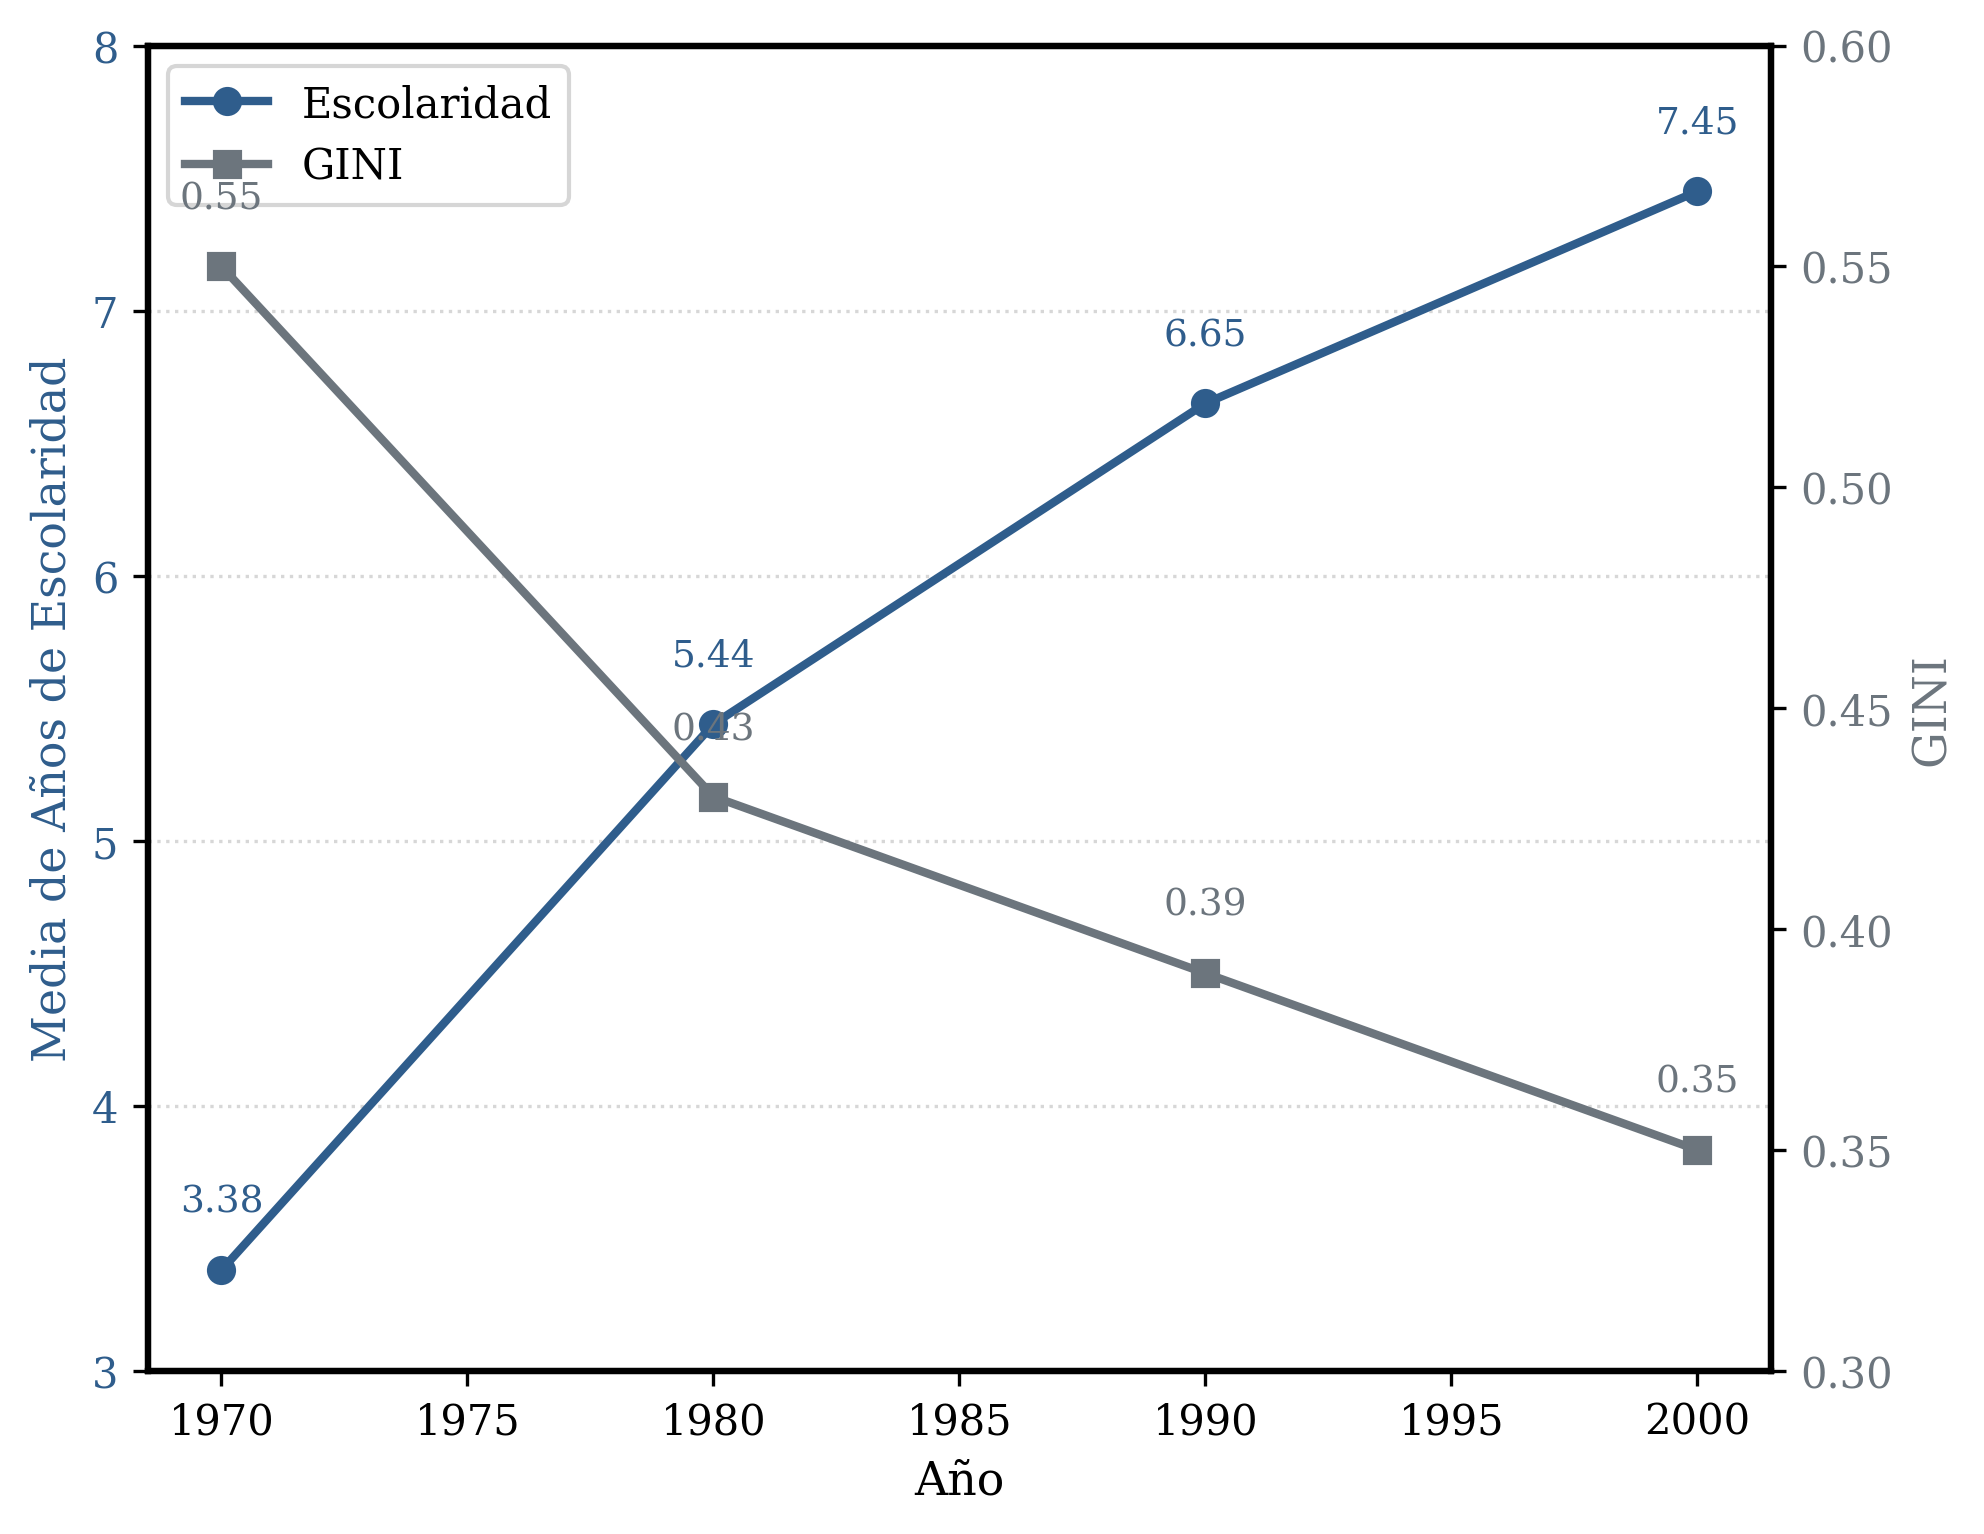

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os

# =====================================================
# FIGURE NUMBER
# =====================================================
FIG_NUM = '1.3'

# =====================================================
# UNIFIED ACADEMIC STYLE
# =====================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# =====================================================
# DATOS
# =====================================================
years = [1970, 1980, 1990, 2000]
escolaridad = [3.38, 5.44, 6.65, 7.45]
gini = [0.55, 0.43, 0.39, 0.35]

# =====================================================
# CONFIGURACIÓN DE LA FIGURA
# =====================================================
fig, ax1 = plt.subplots(figsize=(6.5, 5), constrained_layout=True)

# Colores armonizados con la paleta base
color_blue = '#2F5D8C'   # azul oscuro para escolaridad
color_gray = '#6C757D'   # gris medio para GINI

# --- Eje izquierdo: Escolaridad ---
ax1.set_xlabel('Año', fontsize=11)
ax1.set_ylabel('Media de Años de Escolaridad', color=color_blue, fontsize=11)
ax1.plot(years, escolaridad, color=color_blue, marker='o', linewidth=2, markersize=6, label='Escolaridad')
ax1.tick_params(axis='y', labelcolor=color_blue)
ax1.set_ylim(3.0, 8.0)

# --- Eje derecho: GINI ---
ax2 = ax1.twinx()
ax2.set_ylabel('GINI', color=color_gray, fontsize=11)
ax2.plot(years, gini, color=color_gray, marker='s', linewidth=2, markersize=6, label='GINI')
ax2.tick_params(axis='y', labelcolor=color_gray)
ax2.set_ylim(0.30, 0.60)

# --- Etiquetas de valor con separación vertical ---
def add_labels(ax, x_data, y_data, color, offset_points=14):
    for x, y in zip(x_data, y_data):
        ax.annotate(f"{y:.2f}",
                    (x, y),
                    textcoords="offset points",
                    xytext=(0, offset_points),
                    ha='center',
                    color=color,
                    fontsize=9)

add_labels(ax1, years, escolaridad, color_blue, offset_points=14)
add_labels(ax2, years, gini, color_gray, offset_points=14)

# --- Rejilla (solo eje Y del eje izquierdo) ---
ax1.grid(axis='y', linestyle=':', alpha=0.5)

# --- Bordes negros para ambos ejes ---
for spine in ax1.spines.values():
    spine.set_linewidth(1.5)
    spine.set_edgecolor('black')
for spine in ax2.spines.values():
    spine.set_linewidth(1.5)
    spine.set_edgecolor('black')

# --- Leyenda combinada ---
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color=color_blue, lw=2, marker='o', markersize=6),
                Line2D([0], [0], color=color_gray, lw=2, marker='s', markersize=6)]
ax1.legend(custom_lines, ['Escolaridad', 'GINI'], frameon=True, loc='best', fontsize=10)

# =====================================================
# GUARDADO EN outputs/figures
# =====================================================
output_dir = 'outputs/figures'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'), bbox_inches='tight')

# Si deseas visualizar, descomenta:
# plt.show()

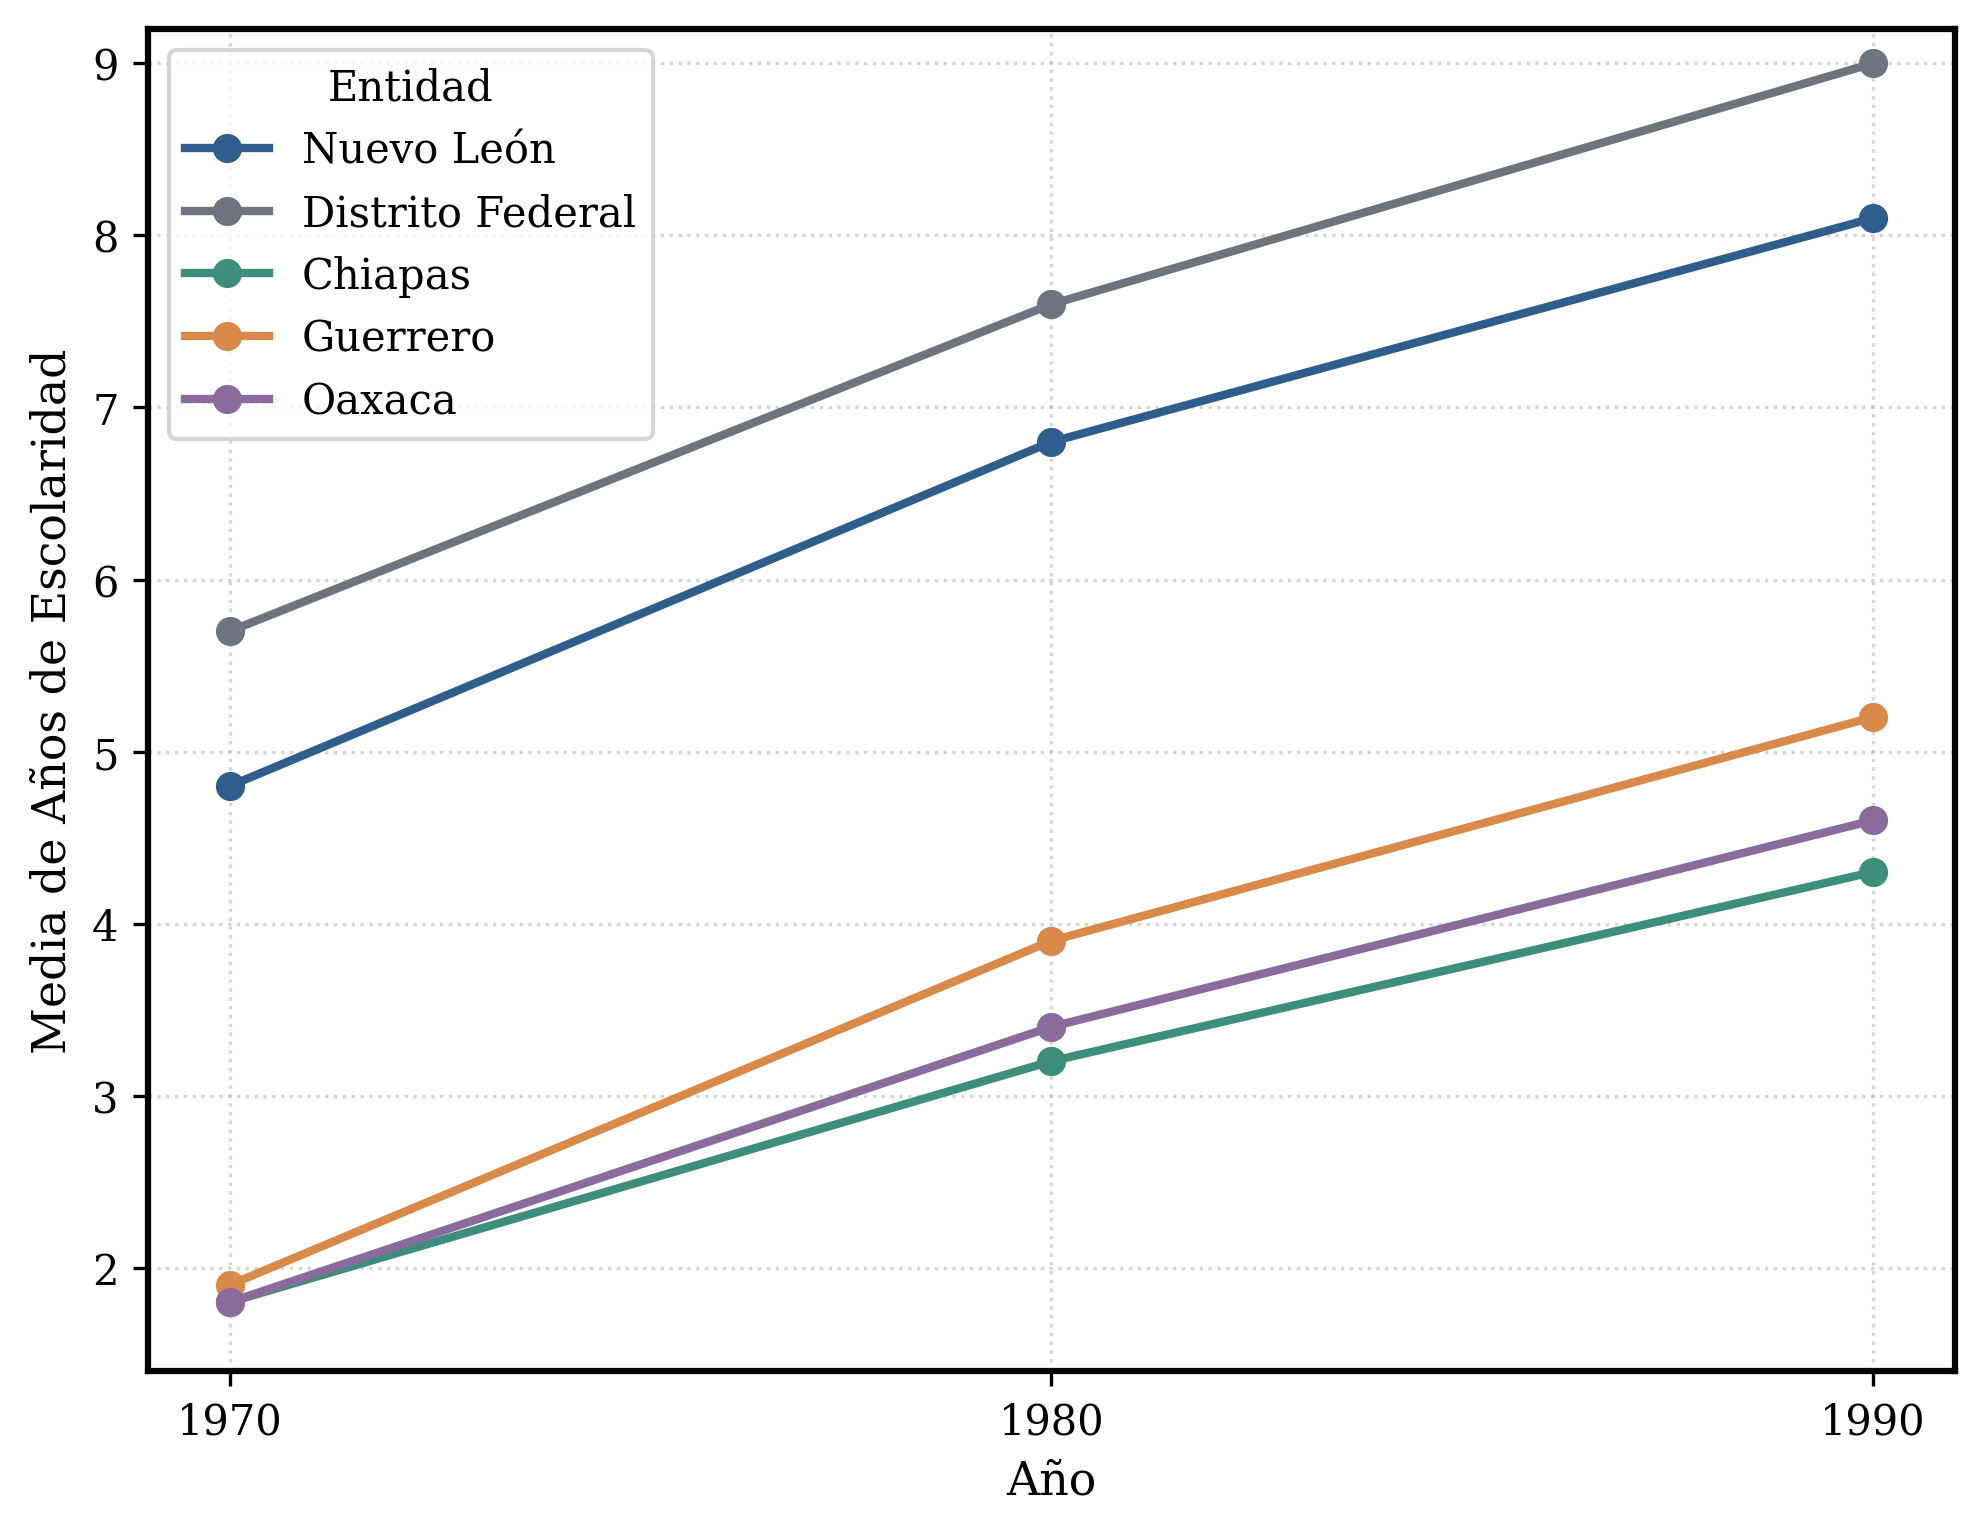

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# =====================================================
# FIGURE NUMBER
# =====================================================
FIG_NUM = '1.4'

# =====================================================
# UNIFIED ACADEMIC STYLE
# =====================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# =====================================================
# DATOS
# =====================================================
data = {
    'Año': [1970, 1980, 1990],
    'Distrito Federal': [5.7, 7.6, 9.0],
    'Nuevo León': [4.8, 6.8, 8.1],
    'Guerrero': [1.9, 3.9, 5.2],
    'Oaxaca': [1.8, 3.4, 4.6],
    'Chiapas': [1.8, 3.2, 4.3]
}
df = pd.DataFrame(data)
df.set_index('Año', inplace=True)

# =====================================================
# CONFIGURACIÓN DE LA FIGURA
# =====================================================
fig, ax = plt.subplots(figsize=(6.5, 5), constrained_layout=True)

# Paleta de colores armonizada con los dos colores base
# (azul oscuro, gris, y tres tonos complementarios)
colors = ['#2F5D8C', '#6C757D', '#3E8E7E', '#D98A4A', '#8B6B9C']

# Orden de las entidades para que coincida con la leyenda original
entidades = ['Nuevo León', 'Distrito Federal', 'Chiapas', 'Guerrero', 'Oaxaca']

# Graficar cada entidad con su color correspondiente
for i, entidad in enumerate(entidades):
    ax.plot(df.index, df[entidad], marker='o', linewidth=2,
            color=colors[i], label=entidad)

# =====================================================
# PERSONALIZACIÓN DE EJES Y REJILLA
# =====================================================
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Media de Años de Escolaridad', fontsize=11)

# Ticks del eje X
ax.set_xticks([1970, 1980, 1990])

# Rejilla en ambos ejes (valores en X y Y)
ax.grid(axis='both', linestyle=':', alpha=0.5)

# Límites para dar aire a la gráfica
ax.set_ylim(1.4, 9.2)

# Bordes negros
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_edgecolor('black')

# =====================================================
# LEYENDA
# =====================================================
ax.legend(title='Entidad', frameon=True, loc='upper left', fontsize=10, title_fontsize=10)

# =====================================================
# GUARDADO EN outputs/figures
# =====================================================
output_dir = 'outputs/figures'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'), bbox_inches='tight')

# Si se desea visualizar, descomentar:
# plt.show()

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
import os

# =====================================================
# ESTILO UNIFICADO (obligatorio para todas las figuras)
# =====================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# =====================================================
# DATOS (mismos que proporcionaste)
# =====================================================
data = {
    'Ciclo': [
        '1970-1971', '1971-1972', '1972-1973', '1973-1974', '1974-1975', '1975-1976', '1976-1977', '1977-1978', '1978-1979', '1979-1980',
        '1980-1981', '1981-1982', '1982-1983', '1983-1984', '1984-1985', '1985-1986', '1986-1987', '1987-1988', '1988-1989', '1989-1990',
        '1990-1991', '1991-1992', '1992-1993', '1993-1994', '1994-1995', '1995-1996', '1996-1997', '1997-1998', '1998-1999', '1999-2000',
        '2000-2001', '2001-2002', '2002-2003', '2003-2004', '2004-2005', '2005-2006', '2006-2007', '2007-2008', '2008-2009', '2009-2010',
        '2010-2011', '2011-2012', '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2017-2018', '2018-2019', '2019-2020',
        '2020-2021', '2021-2022', '2022-2023', '2023-2024', '2024-2025'
    ],
    'Escuelas_MS': [
        1100, 1180, 1327, 1481, 1616, 1790, 1954, 2112, 2303, 2585,
        2908, 3405, 3738, 3813, 4952, 5441, 5800, 5586, 5832, 6011,
        6222, 6548, 6833, 7167, 7633, 7886, 8280, 8817, 9299, 9542,
        9761, 10587, 11327, 11938, 12382, 12841, 13194, 13493, 14103, 14427,
        15110, 15427, 15990, 17245, 19217, 20731, 21160, 21288, 21460, 21512,
        21414, 21346, 21266, 21249, 21175
    ],
    'Escuelas_S': [
        385, 393, 412, 456, 484, 531, 606, 676, 754, 813,
        892, 938, 1039, 1305, 1540, 1717, 1796, 1930, 1999, 2077,
        2123, 2296, 2239, 2535, 2708, 3002, 3182, 3416, 3602, 3815,
        4049, 4196, 4486, 4585, 4719, 5116, 5239, 5420, 5560, 5981,
        6289, 6878, 6796, 6922, 8663, 7107, 7162, 7451, 7709, 8120,
        8318, 8539, 8789, 8966, 9263
    ],
    'Alumnos_MS': [
        369299, 426330, 514070, 596706, 705900, 797845, 887171, 987694, 1148466, 1242353,
        1388132, 1564852, 1725601, 1786658, 1851769, 1961936, 1963187, 2012268, 2070471, 2091920,
        2100520, 2136194, 2177225, 2244134, 2343477, 2438676, 2606099, 2713897, 2805534, 2892846,
        2955783, 3120475, 3295272, 3443740, 3547924, 3658754, 3742943, 3830042, 3923822, 4054709,
        4187528, 4333589, 4443792, 5287418, 5017281, 5286867, 5484559, 5640841, 5608220, 5544608,
        5353499, 5230594, 5379859, 5508572, 5492491
    ],
    'Alumnos_S': [
        271275, 316077, 355226, 403897, 471717, 543112, 569266, 609070, 740073, 848875,
        935789, 1007123, 1052762, 1121252, 1141531, 1199120, 1191997, 1244888, 1256942, 1258725,
        1252027, 1316315, 1306621, 1368027, 1420461, 1532846, 1612318, 1727484, 1837884, 1962763,
        2047895, 2147075, 2236791, 2322781, 2384858, 2446726, 2528664, 2623367, 2705190, 2847376,
        2981313, 3161195, 3300348, 3882625, 4032992, 4244401, 4430248, 4561792, 4705400, 4931200,
        4983206, 5069111, 5192618, 5393387, 5519791
    ],
    'Docentes_MS': [
        27837, 31075, 36250, 40249, 44672, 48174, 55904, 64231, 69947, 75403,
        84239, 96174, 104804, 112773, 126705, 136143, 141071, 136567, 142061, 146029,
        145382, 147667, 151073, 157433, 166921, 177009, 182185, 186859, 197892, 203891,
        210033, 219468, 233844, 242142, 248282, 255929, 258939, 264079, 272817, 269301,
        278269, 285974, 288464, 381622, 407850, 427389, 424567, 430459, 428396, 420442,
        416013, 419513, 420463, 425826, 423587
    ],
    'Docentes_S': [
        25056, 28065, 31037, 36350, 41893, 47529, 43114, 52140, 62334, 69494,
        73789, 74944, 87716, 92338, 101261, 108002, 115902, 120341, 128481, 133068,
        134424, 135444, 138785, 142261, 152630, 163843, 170350, 177988, 192406, 201534,
        208692, 219804, 231558, 241236, 251740, 261889, 274618, 285958, 291268, 309952,
        315179, 342269, 352007, 348922, 417134, 452969, 460234, 466191, 486804, 467065,
        500693, 483868, 490309, 496357, 519190
    ]
}

df = pd.DataFrame(data)

# Dividir en dos períodos
idx_split = df[df['Ciclo'] == '1990-1991'].index[0]
df_p1 = df.iloc[:idx_split]   # 1970-1971 a 1989-1990
df_p2 = df.iloc[idx_split:]   # 1990-1991 en adelante

# =====================================================
# FUNCIÓN PARA GENERAR Y GUARDAR CADA FIGURA
# =====================================================
def generar_y_guardar(df_sub, col_ms, col_s, fig_num, ylabel='Cantidad', mostrar_reformas=False):
    """
    Crea una gráfica de barras agrupadas para Media Superior y Superior,
    aplica el estilo unificado y guarda en outputs/figures con el número dado.
    """
    fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)

    x = np.arange(len(df_sub))
    width = 0.35

    # Colores base de la tesis: #2F5D8C (azul oscuro) y #6C757D (gris)
    # Asignamos azul a Media Superior y gris a Superior
    ax.bar(x - width/2, df_sub[col_ms], width,
           label='Media Superior', color='#2F5D8C', edgecolor='black')
    ax.bar(x + width/2, df_sub[col_s], width,
           label='Superior', color='#6C757D', edgecolor='black')

    # Etiquetas de ejes
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlabel('Ciclo escolar', fontsize=11)

    # Ticks del eje X con rotación
    ax.set_xticks(x)
    ax.set_xticklabels(df_sub['Ciclo'], rotation=60, ha='right', fontsize=9)

    # Leyenda
    ax.legend(frameon=True, fontsize=10, loc='upper left')

    # Rejilla en Y
    ax.grid(axis='y', linestyle=':', alpha=0.5)

    # Formato de números en Y con separador de miles
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

    # Bordes negros en todos los ejes
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

    # Líneas de reformas (solo para el segundo período)
    if mostrar_reformas:
        reformas = {
            '2013-2014': 'Reforma\n2013',
            '2019-2020': 'Reforma\n2019'
        }
        ciclos = df_sub['Ciclo'].tolist()
        y_max = ax.get_ylim()[1]  # altura máxima

        for ciclo, etiqueta in reformas.items():
            if ciclo in ciclos:
                idx = ciclos.index(ciclo)
                ax.axvline(x=idx, color='black', linestyle='--', linewidth=1, alpha=0.7)
                ax.text(idx, y_max * 0.95, etiqueta,
                        ha='center', va='top', fontsize=9,
                        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

    # Guardado
    output_dir = 'outputs/figures'
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(os.path.join(output_dir, f'Figura_{fig_num}.pdf'), bbox_inches='tight')
    plt.savefig(os.path.join(output_dir, f'Figura_{fig_num}.svg'), bbox_inches='tight')
    plt.close(fig)  # libera memoria

# =====================================================
# GENERACIÓN DE LAS SEIS FIGURAS
# =====================================================

# 1.6 Escuelas (1970-1990)
generar_y_guardar(df_p1, 'Escuelas_MS', 'Escuelas_S', '1.6',
                  ylabel='Número de escuelas', mostrar_reformas=False)

# 1.7 Alumnos (1970-1990)
generar_y_guardar(df_p1, 'Alumnos_MS', 'Alumnos_S', '1.7',
                  ylabel='Número de alumnos', mostrar_reformas=False)

# 1.8 Docentes (1970-1990)
generar_y_guardar(df_p1, 'Docentes_MS', 'Docentes_S', '1.8',
                  ylabel='Número de docentes', mostrar_reformas=False)

# 1.12 Escuelas (1990-2024) con reformas
generar_y_guardar(df_p2, 'Escuelas_MS', 'Escuelas_S', '1.12',
                  ylabel='Número de escuelas', mostrar_reformas=True)

# 1.13 Alumnos (1990-2024) con reformas
generar_y_guardar(df_p2, 'Alumnos_MS', 'Alumnos_S', '1.13',
                  ylabel='Número de alumnos', mostrar_reformas=True)

# 1.14 Docentes (1990-2024) con reformas
generar_y_guardar(df_p2, 'Docentes_MS', 'Docentes_S', '1.14',
                  ylabel='Número de docentes', mostrar_reformas=True)

print("Seis figuras generadas y guardadas en outputs/figures/")

Seis figuras generadas y guardadas en outputs/figures/


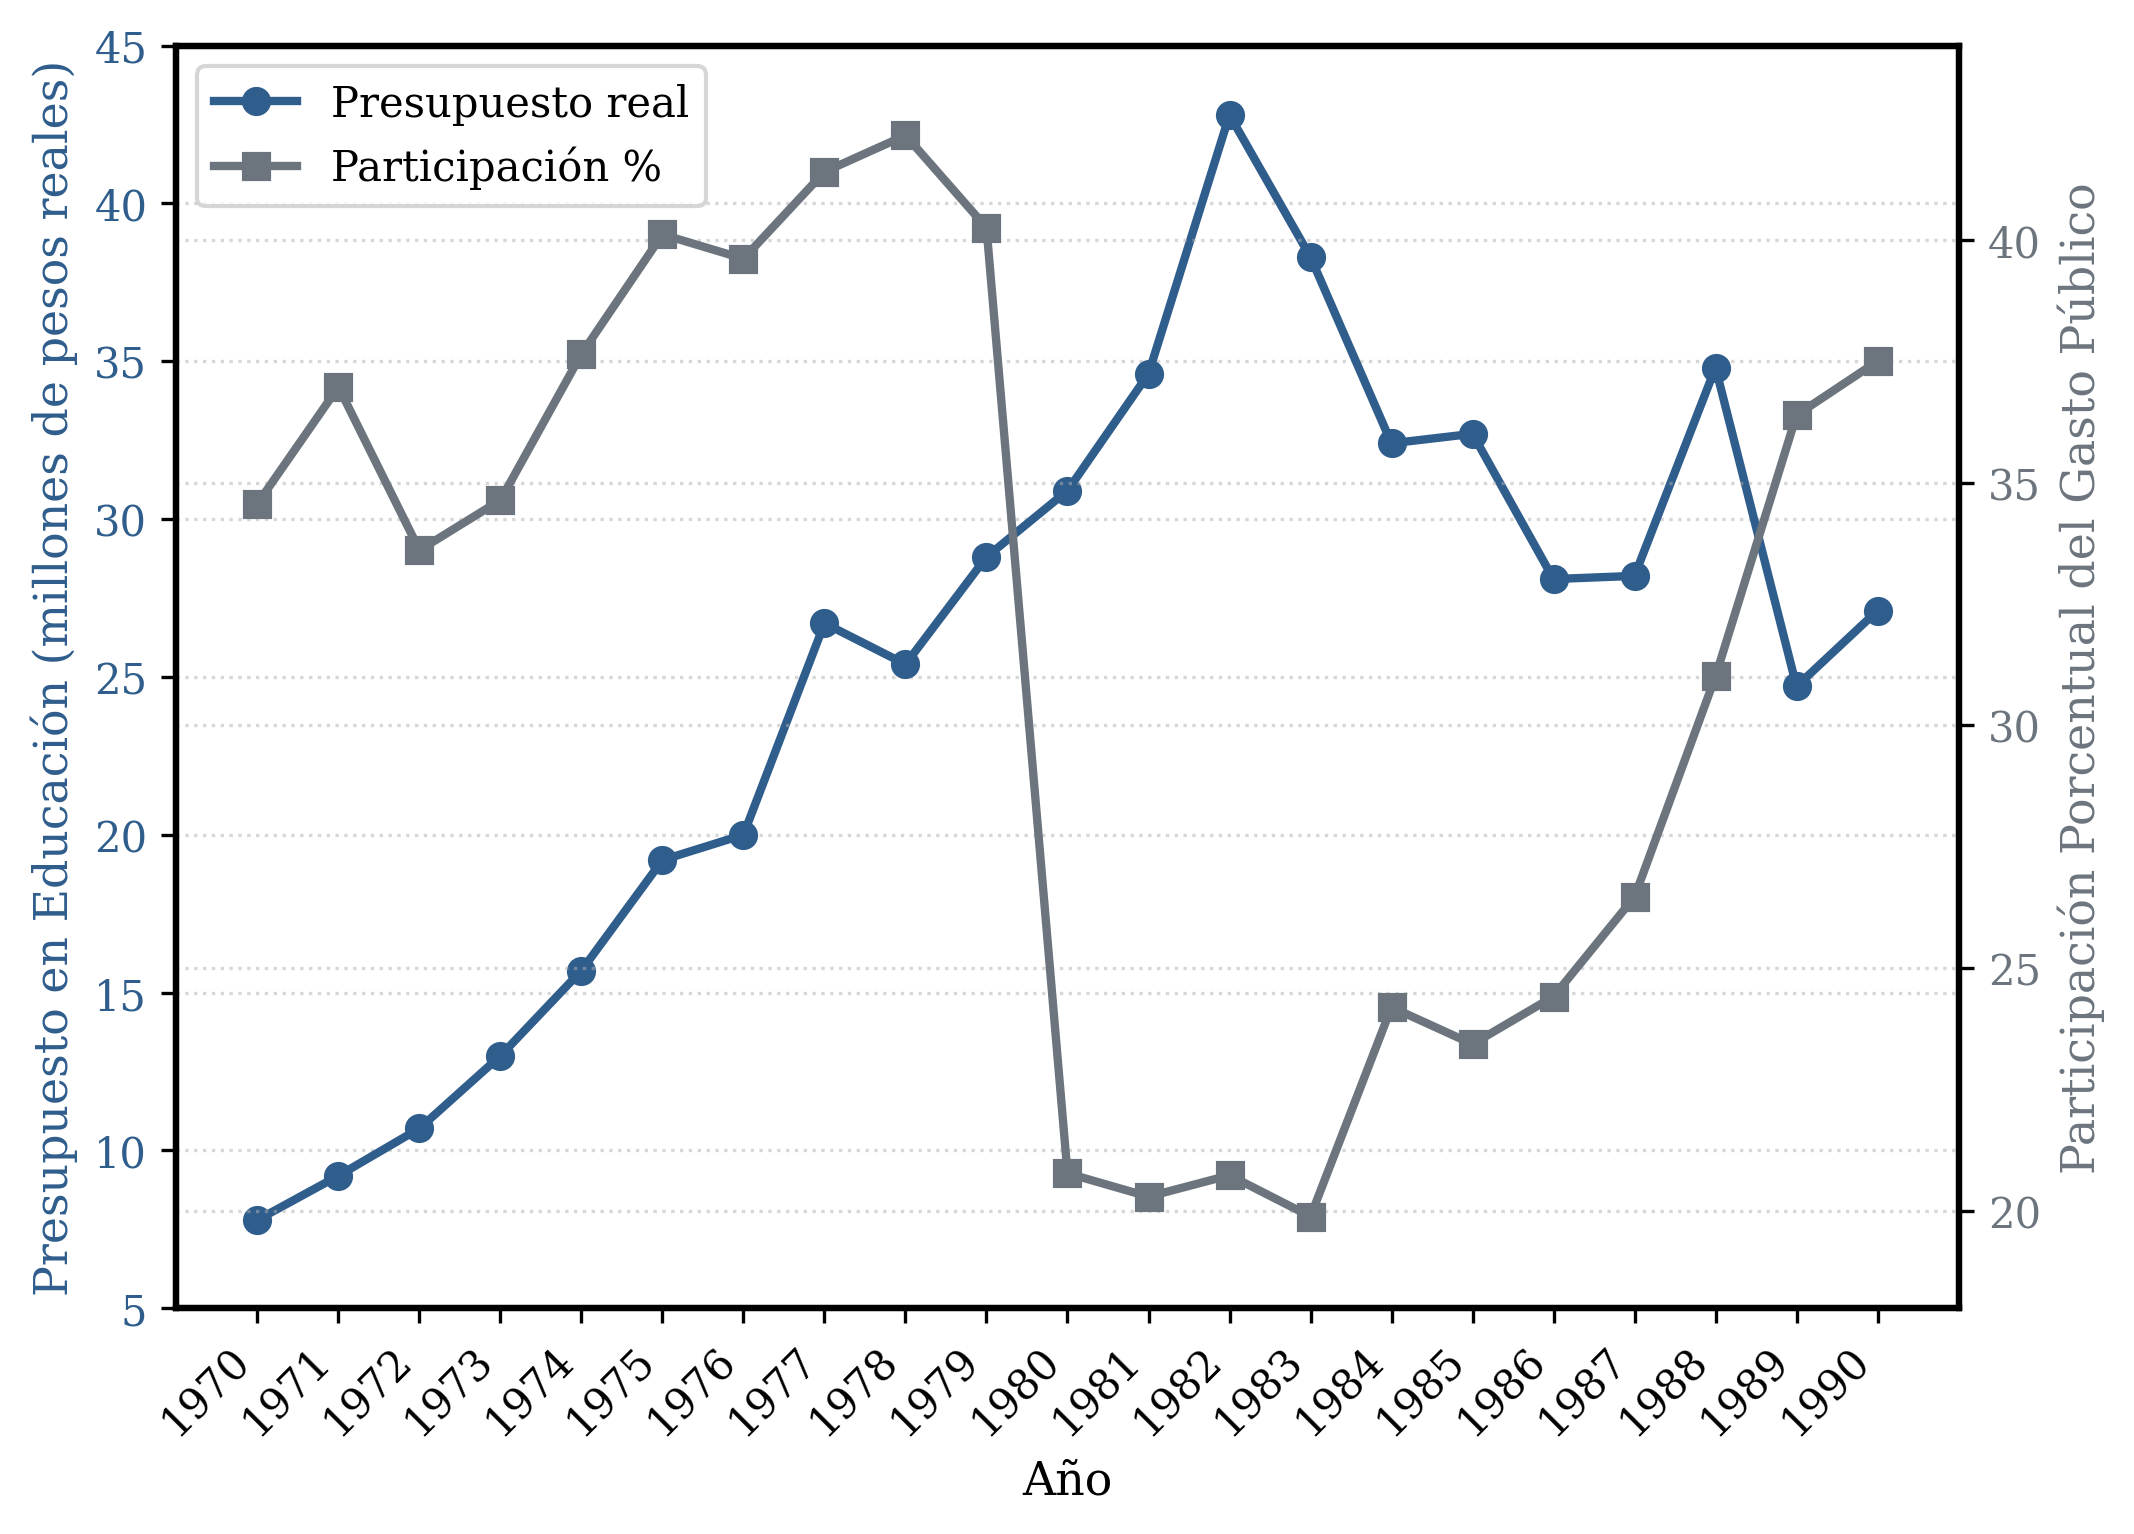

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

# =====================================================
# FIGURE NUMBER
# =====================================================
FIG_NUM = '1.9'

# =====================================================
# UNIFIED ACADEMIC STYLE
# =====================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# =====================================================
# DATOS
# =====================================================
years = list(range(1970, 1991))

budget_real = [
    7.8, 9.2, 10.7, 13.0, 15.7, 19.2, 20.0, 26.7, 25.4, 28.8,
    30.9, 34.6, 42.8, 38.3, 32.4, 32.7, 28.1, 28.2, 34.8, 24.7, 27.1
]

participation = [
    34.57, 36.97, 33.61, 34.64, 37.65, 40.11, 39.61, 41.40, 42.15, 40.25,
    20.78, 20.30, 20.74, 19.89, 24.20, 23.44, 24.42, 26.47, 31.01, 36.39, 37.50
]

# =====================================================
# FIGURA CON DOS EJES Y (twinx)
# =====================================================
fig, ax1 = plt.subplots(figsize=(7, 5), constrained_layout=True)

# Colores de la paleta base
color_edu = '#2F5D8C'      # azul oscuro para presupuesto
color_part = '#6C757D'     # gris medio para participación

# --- Eje izquierdo: presupuesto real ---
ax1.set_xlabel('Año', fontsize=11)
ax1.set_ylabel('Presupuesto en Educación (millones de pesos reales)', color=color_edu, fontsize=11)
line1 = ax1.plot(years, budget_real, color=color_edu, marker='o', linewidth=2, label='Educación (millones de pesos reales)')
ax1.tick_params(axis='y', labelcolor=color_edu)
ax1.set_ylim(5, 45)

# --- Eje derecho: participación porcentual ---
ax2 = ax1.twinx()
ax2.set_ylabel('Participación Porcentual del Gasto Público', color=color_part, fontsize=11)
line2 = ax2.plot(years, participation, color=color_part, marker='s', linewidth=2, label='Participación %')
ax2.tick_params(axis='y', labelcolor=color_part)
ax2.set_ylim(18, 44)

# --- Eje X: todos los años con rotación ---
ax1.set_xticks(years)
ax1.set_xticklabels(years, rotation=45, ha='right', fontsize=10)

# --- Rejilla en ambos ejes (solo eje Y para no saturar) ---
ax1.grid(axis='y', linestyle=':', alpha=0.5)
ax2.grid(axis='y', linestyle=':', alpha=0.5)  # opcional, pero ayuda a leer ambos valores

# --- Bordes negros en todos los spines ---
for spine in ax1.spines.values():
    spine.set_linewidth(1.5)
    spine.set_edgecolor('black')
for spine in ax2.spines.values():
    spine.set_linewidth(1.5)
    spine.set_edgecolor('black')

# --- Leyenda combinada (manual) ---
from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color=color_edu, lw=2, marker='o', markersize=6),
    Line2D([0], [0], color=color_part, lw=2, marker='s', markersize=6)
]
ax1.legend(custom_lines, ['Presupuesto real', 'Participación %'],
           frameon=True, loc='upper left', fontsize=10)

# =====================================================
# GUARDADO EN outputs/figures
# =====================================================
output_dir = 'outputs/figures'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'), bbox_inches='tight')

# Si se desea visualizar, descomentar:
# plt.show()

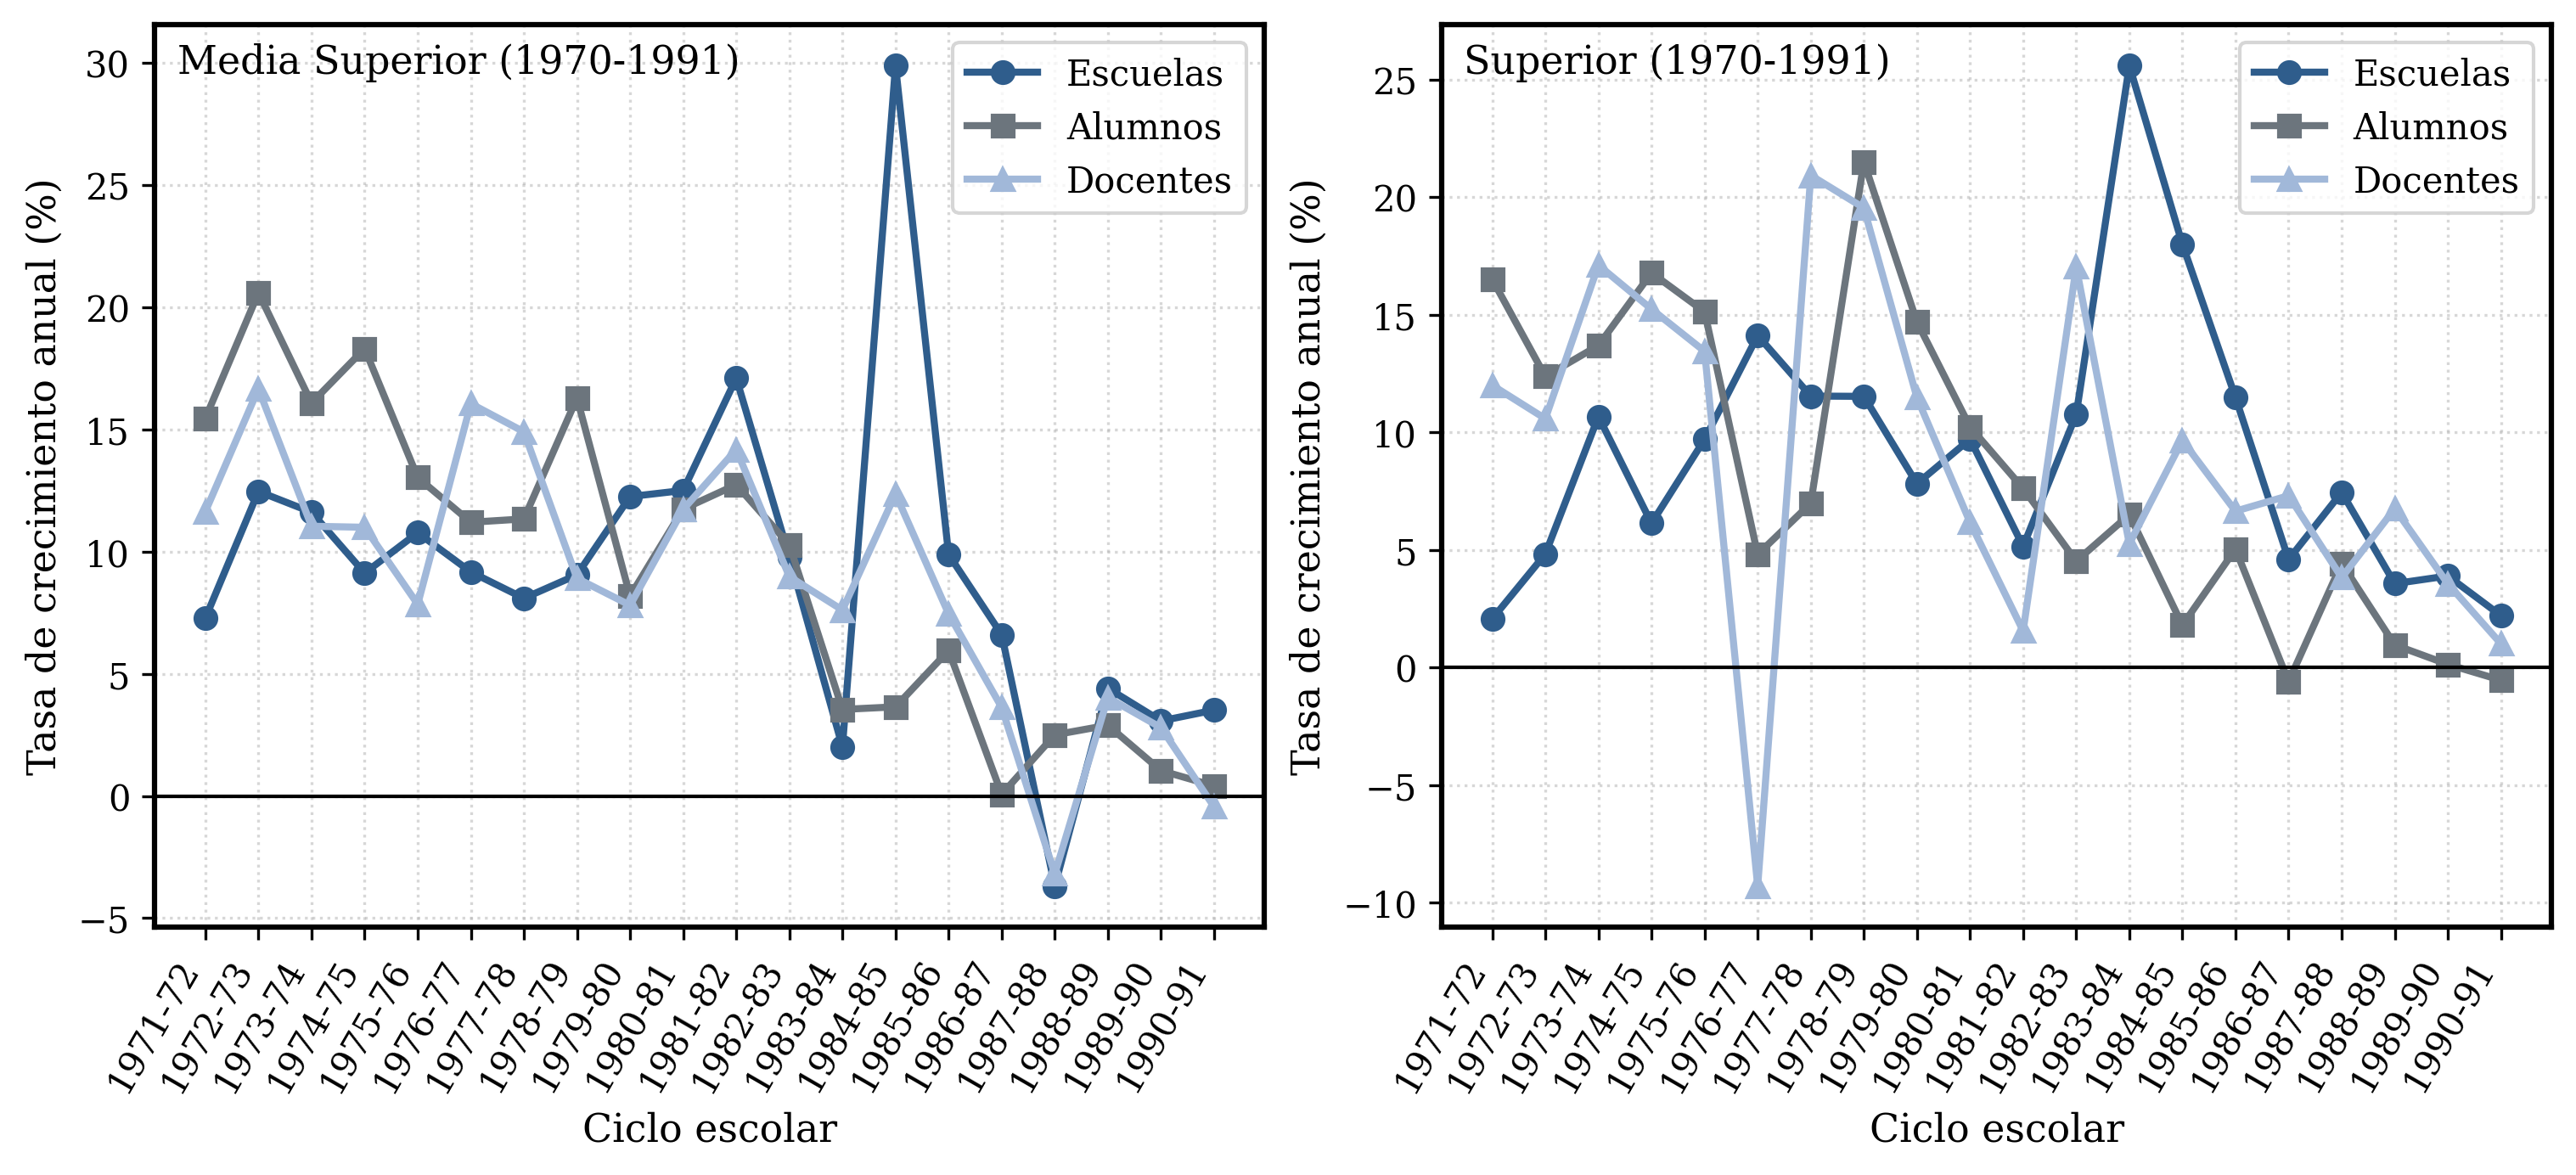

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# =====================================================
# FIGURE NUMBER
# =====================================================
FIG_NUM = '1.10'

# =====================================================
# UNIFIED ACADEMIC STYLE
# =====================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# =====================================================
# DATOS (1970-1991)
# =====================================================
data_70_90 = {
    'Ciclo': [
        '1970-71', '1971-72', '1972-73', '1973-74', '1974-75', '1975-76', '1976-77', '1977-78', '1978-79', '1979-80',
        '1980-81', '1981-82', '1982-83', '1983-84', '1984-85', '1985-86', '1986-87', '1987-88', '1988-89', '1989-90',
        '1990-91'
    ],
    'Escuelas_MS': [1100, 1180, 1327, 1481, 1616, 1790, 1954, 2112, 2303, 2585, 2908, 3405, 3738, 3813, 4952, 5441, 5800, 5586, 5832, 6011, 6222],
    'Alumnos_MS': [369299, 426330, 514070, 596706, 705900, 797845, 887171, 987694, 1148466, 1242353, 1388132, 1564852, 1725601, 1786658, 1851769, 1961936, 1963187, 2012268, 2070471, 2091920, 2100520],
    'Docentes_MS': [27837, 31075, 36250, 40249, 44672, 48174, 55904, 64231, 69947, 75403, 84239, 96174, 104804, 112773, 126705, 136143, 141071, 136567, 142061, 146029, 145382],
    'Escuelas_S': [385, 393, 412, 456, 484, 531, 606, 676, 754, 813, 892, 938, 1039, 1305, 1540, 1717, 1796, 1930, 1999, 2077, 2123],
    'Alumnos_S': [271275, 316077, 355226, 403897, 471717, 543112, 569266, 609070, 740073, 848875, 935789, 1007123, 1052762, 1121252, 1141531, 1199120, 1191997, 1244888, 1256942, 1258725, 1252027],
    'Docentes_S': [25056, 28065, 31037, 36350, 41893, 47529, 43114, 52140, 62334, 69494, 73789, 74944, 87716, 92338, 101261, 108002, 115902, 120341, 128481, 133068, 134424]
}

df = pd.DataFrame(data_70_90)

# --- Tasas de crecimiento anual (%) ---
df_growth = df[['Ciclo']].copy()
cols_to_calc = ['Escuelas_MS', 'Alumnos_MS', 'Docentes_MS', 'Escuelas_S', 'Alumnos_S', 'Docentes_S']
for col in cols_to_calc:
    df_growth[col] = df[col].pct_change() * 100
df_growth = df_growth.dropna()  # elimina la primera fila con NaN

# =====================================================
# FUNCIÓN PARA GRAFICAR UN SUBPLOT
# =====================================================
def plot_growth(ax, nivel, suffix):
    """
    Dibuja las tasas de crecimiento para escuelas, alumnos y docentes
    de un nivel (MS o S) en el eje 'ax'.
    """
    col_esc = f'Escuelas_{suffix}'
    col_alum = f'Alumnos_{suffix}'
    col_doc = f'Docentes_{suffix}'
    
    # Paleta armonizada con los colores base:
    #   - Escuelas: #2F5D8C (azul oscuro)
    #   - Alumnos:  #6C757D (gris medio)
    #   - Docentes: #A1B8D9 (azul claro, variante del azul)
    colors = {'Escuelas': '#2F5D8C', 'Alumnos': '#6C757D', 'Docentes': '#A1B8D9'}
    markers = {'Escuelas': 'o', 'Alumnos': 's', 'Docentes': '^'}
    
    ax.plot(df_growth['Ciclo'], df_growth[col_esc],
            label='Escuelas', color=colors['Escuelas'], marker=markers['Escuelas'],
            linewidth=2, markersize=6)
    ax.plot(df_growth['Ciclo'], df_growth[col_alum],
            label='Alumnos', color=colors['Alumnos'], marker=markers['Alumnos'],
            linewidth=2, markersize=6)
    ax.plot(df_growth['Ciclo'], df_growth[col_doc],
            label='Docentes', color=colors['Docentes'], marker=markers['Docentes'],
            linewidth=2, markersize=6)
    
    # Etiqueta del nivel (sin título)
    ax.text(0.02, 0.98, nivel, transform=ax.transAxes, ha='left', va='top',
            fontsize=11, weight='normal')
    
    ax.set_ylabel('Tasa de crecimiento anual (%)', fontsize=11)
    ax.set_xlabel('Ciclo escolar', fontsize=11)
    
    # Configuración del eje X
    ax.set_xticks(range(len(df_growth)))
    ax.set_xticklabels(df_growth['Ciclo'], rotation=60, ha='right', fontsize=10)
    
    # Rejilla en ambos ejes (según especificación)
    ax.grid(axis='both', linestyle=':', alpha=0.5)
    
    # Línea de referencia en cero
    ax.axhline(0, color='black', linewidth=1)
    
    # Leyenda con marco
    ax.legend(frameon=True, loc='best', fontsize=10)
    
    # Bordes negros
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

# =====================================================
# FIGURA CON DOS SUBPLOTS EN HORIZONTAL (1×2)
# =====================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

plot_growth(ax1, 'Media Superior (1970-1991)', 'MS')
plot_growth(ax2, 'Superior (1970-1991)', 'S')

# =====================================================
# GUARDADO EN outputs/figures
# =====================================================
output_dir = 'outputs/figures'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'), bbox_inches='tight')

# Si se desea visualizar, descomentar:
# plt.show()

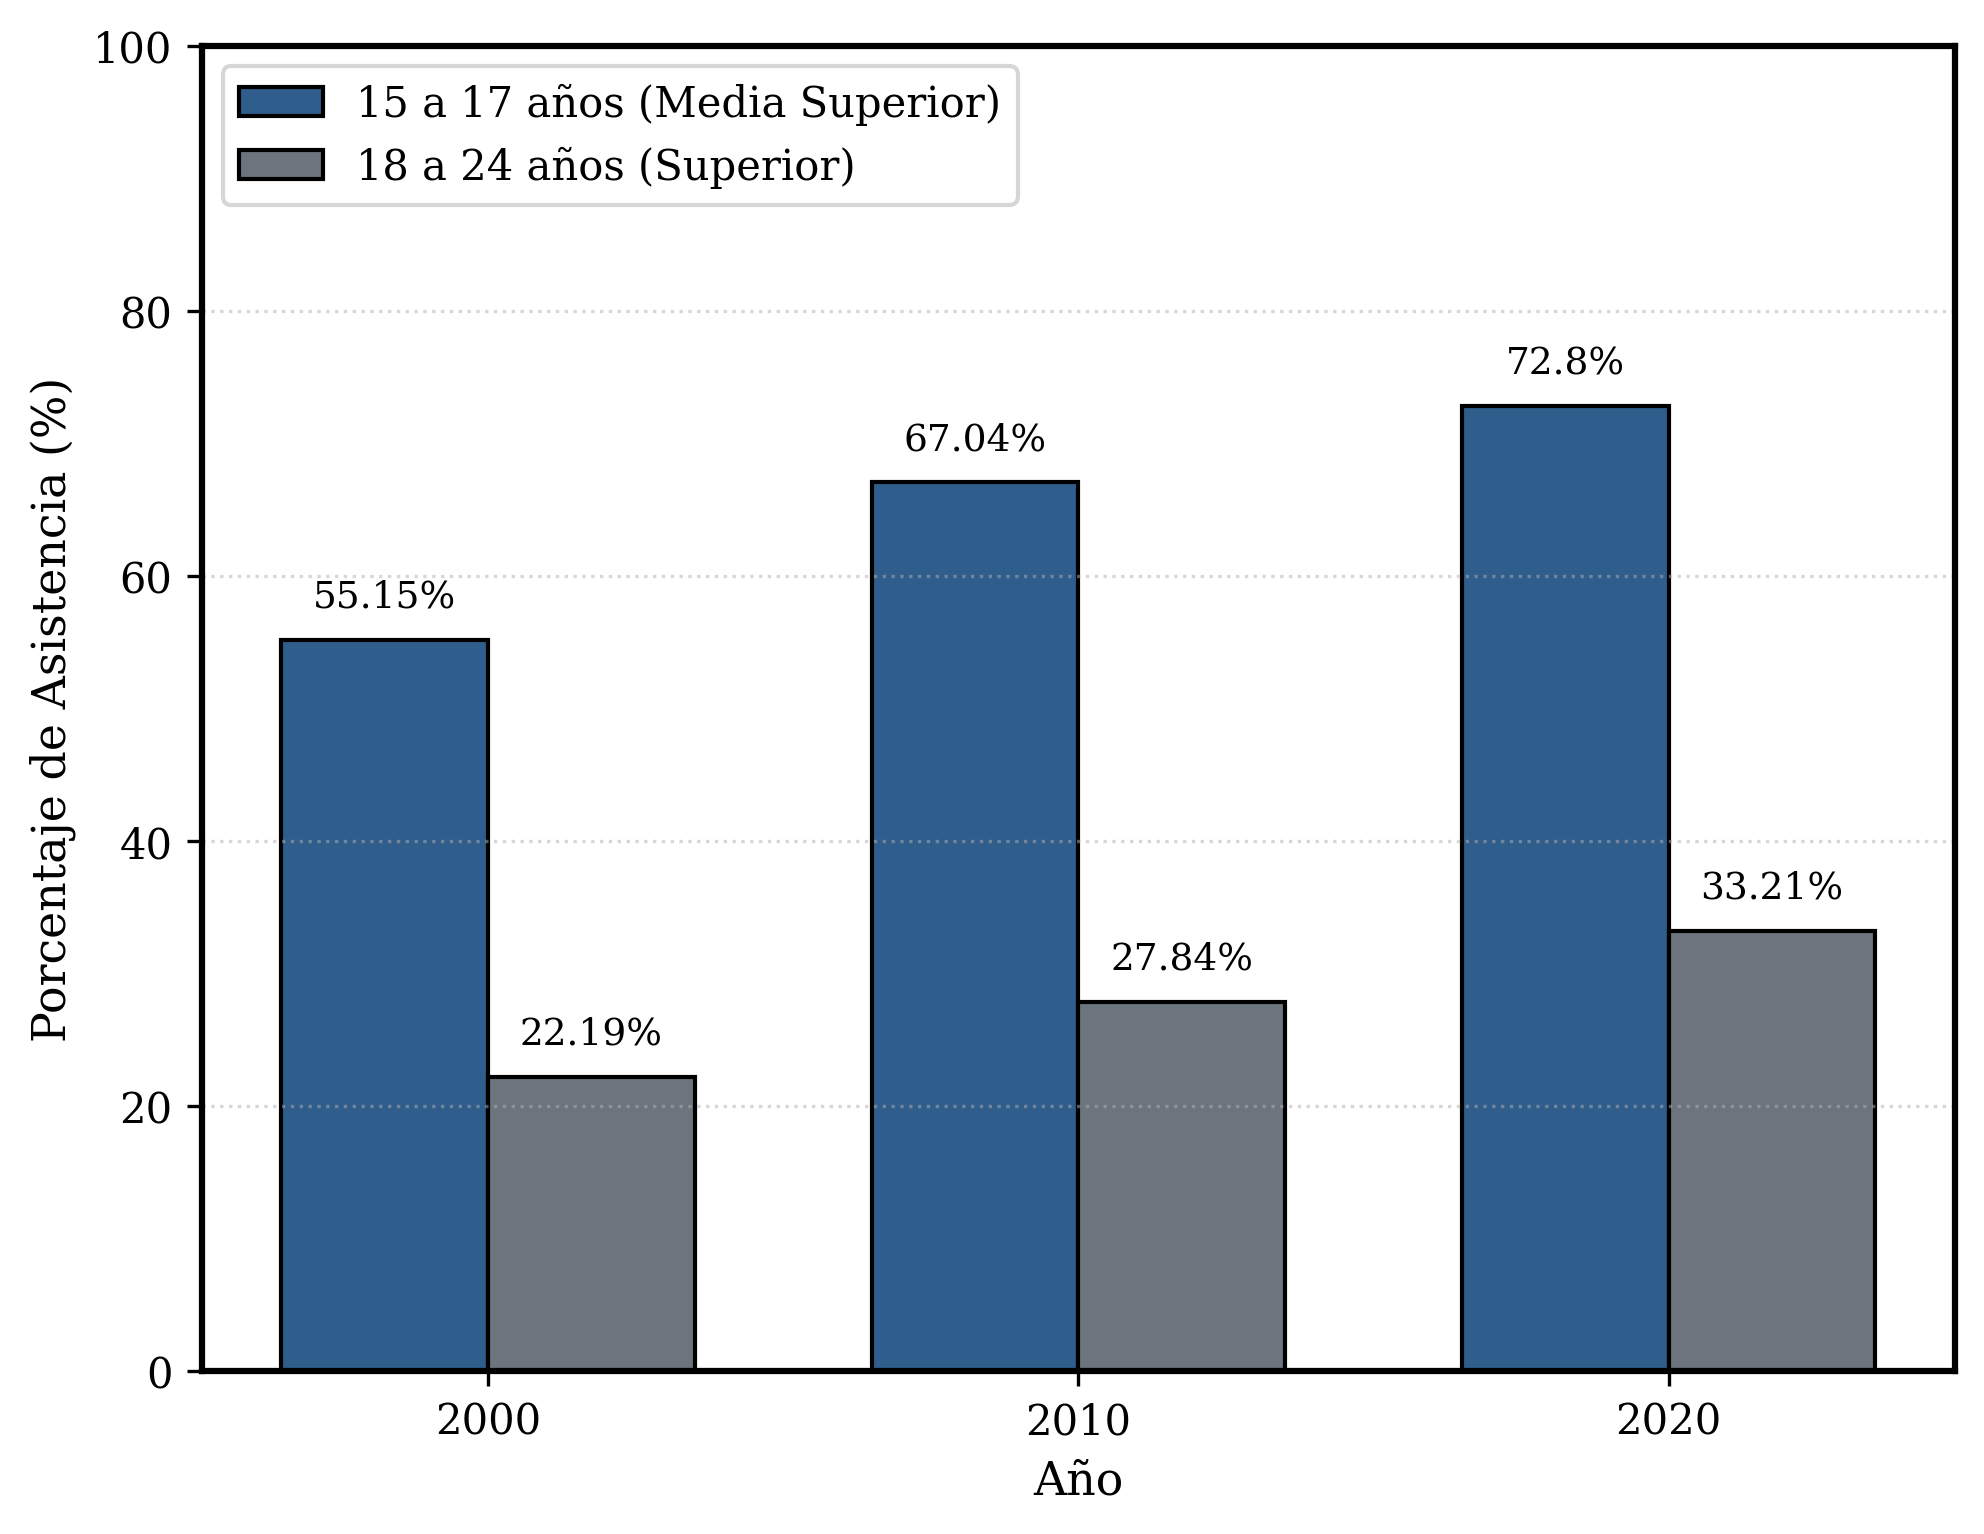

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import os

# =====================================================
# FIGURE NUMBER
# =====================================================
FIG_NUM = '1.11'

# =====================================================
# UNIFIED ACADEMIC STYLE
# =====================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# =====================================================
# DATOS
# =====================================================
anios = ['2000', '2010', '2020']
asiste_15_17 = [55.15, 67.04, 72.80]
asiste_18_24 = [22.19, 27.84, 33.21]

# =====================================================
# CONFIGURACIÓN DE LA FIGURA
# =====================================================
fig, ax = plt.subplots(figsize=(6.5, 5), constrained_layout=True)

x = np.arange(len(anios))
width = 0.35

# Colores de la paleta base: #2F5D8C (azul) y #6C757D (gris)
rects1 = ax.bar(x - width/2, asiste_15_17, width,
                color='#2F5D8C', edgecolor='black',
                label='15 a 17 años (Media Superior)')
rects2 = ax.bar(x + width/2, asiste_18_24, width,
                color='#6C757D', edgecolor='black',
                label='18 a 24 años (Superior)')

# =====================================================
# EJES Y REJILLA
# =====================================================
ax.set_ylabel('Porcentaje de Asistencia (%)', fontsize=11)
ax.set_xlabel('Año', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(anios, fontsize=10)
ax.set_ylim(0, 100)

# Rejilla solo en el eje Y (valores)
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Bordes negros en los ejes
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_edgecolor('black')

# =====================================================
# LEYENDA
# =====================================================
ax.legend(frameon=True, loc='upper left', fontsize=10)

# =====================================================
# ETIQUETAS DE VALOR (con separación vertical)
# =====================================================
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}%',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 6),          # 6 puntos de separación
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=9, color='black')

autolabel(rects1)
autolabel(rects2)

# =====================================================
# GUARDADO EN outputs/figures
# =====================================================
output_dir = 'outputs/figures'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'), bbox_inches='tight')

# Si se desea visualizar, descomentar:
# plt.show()

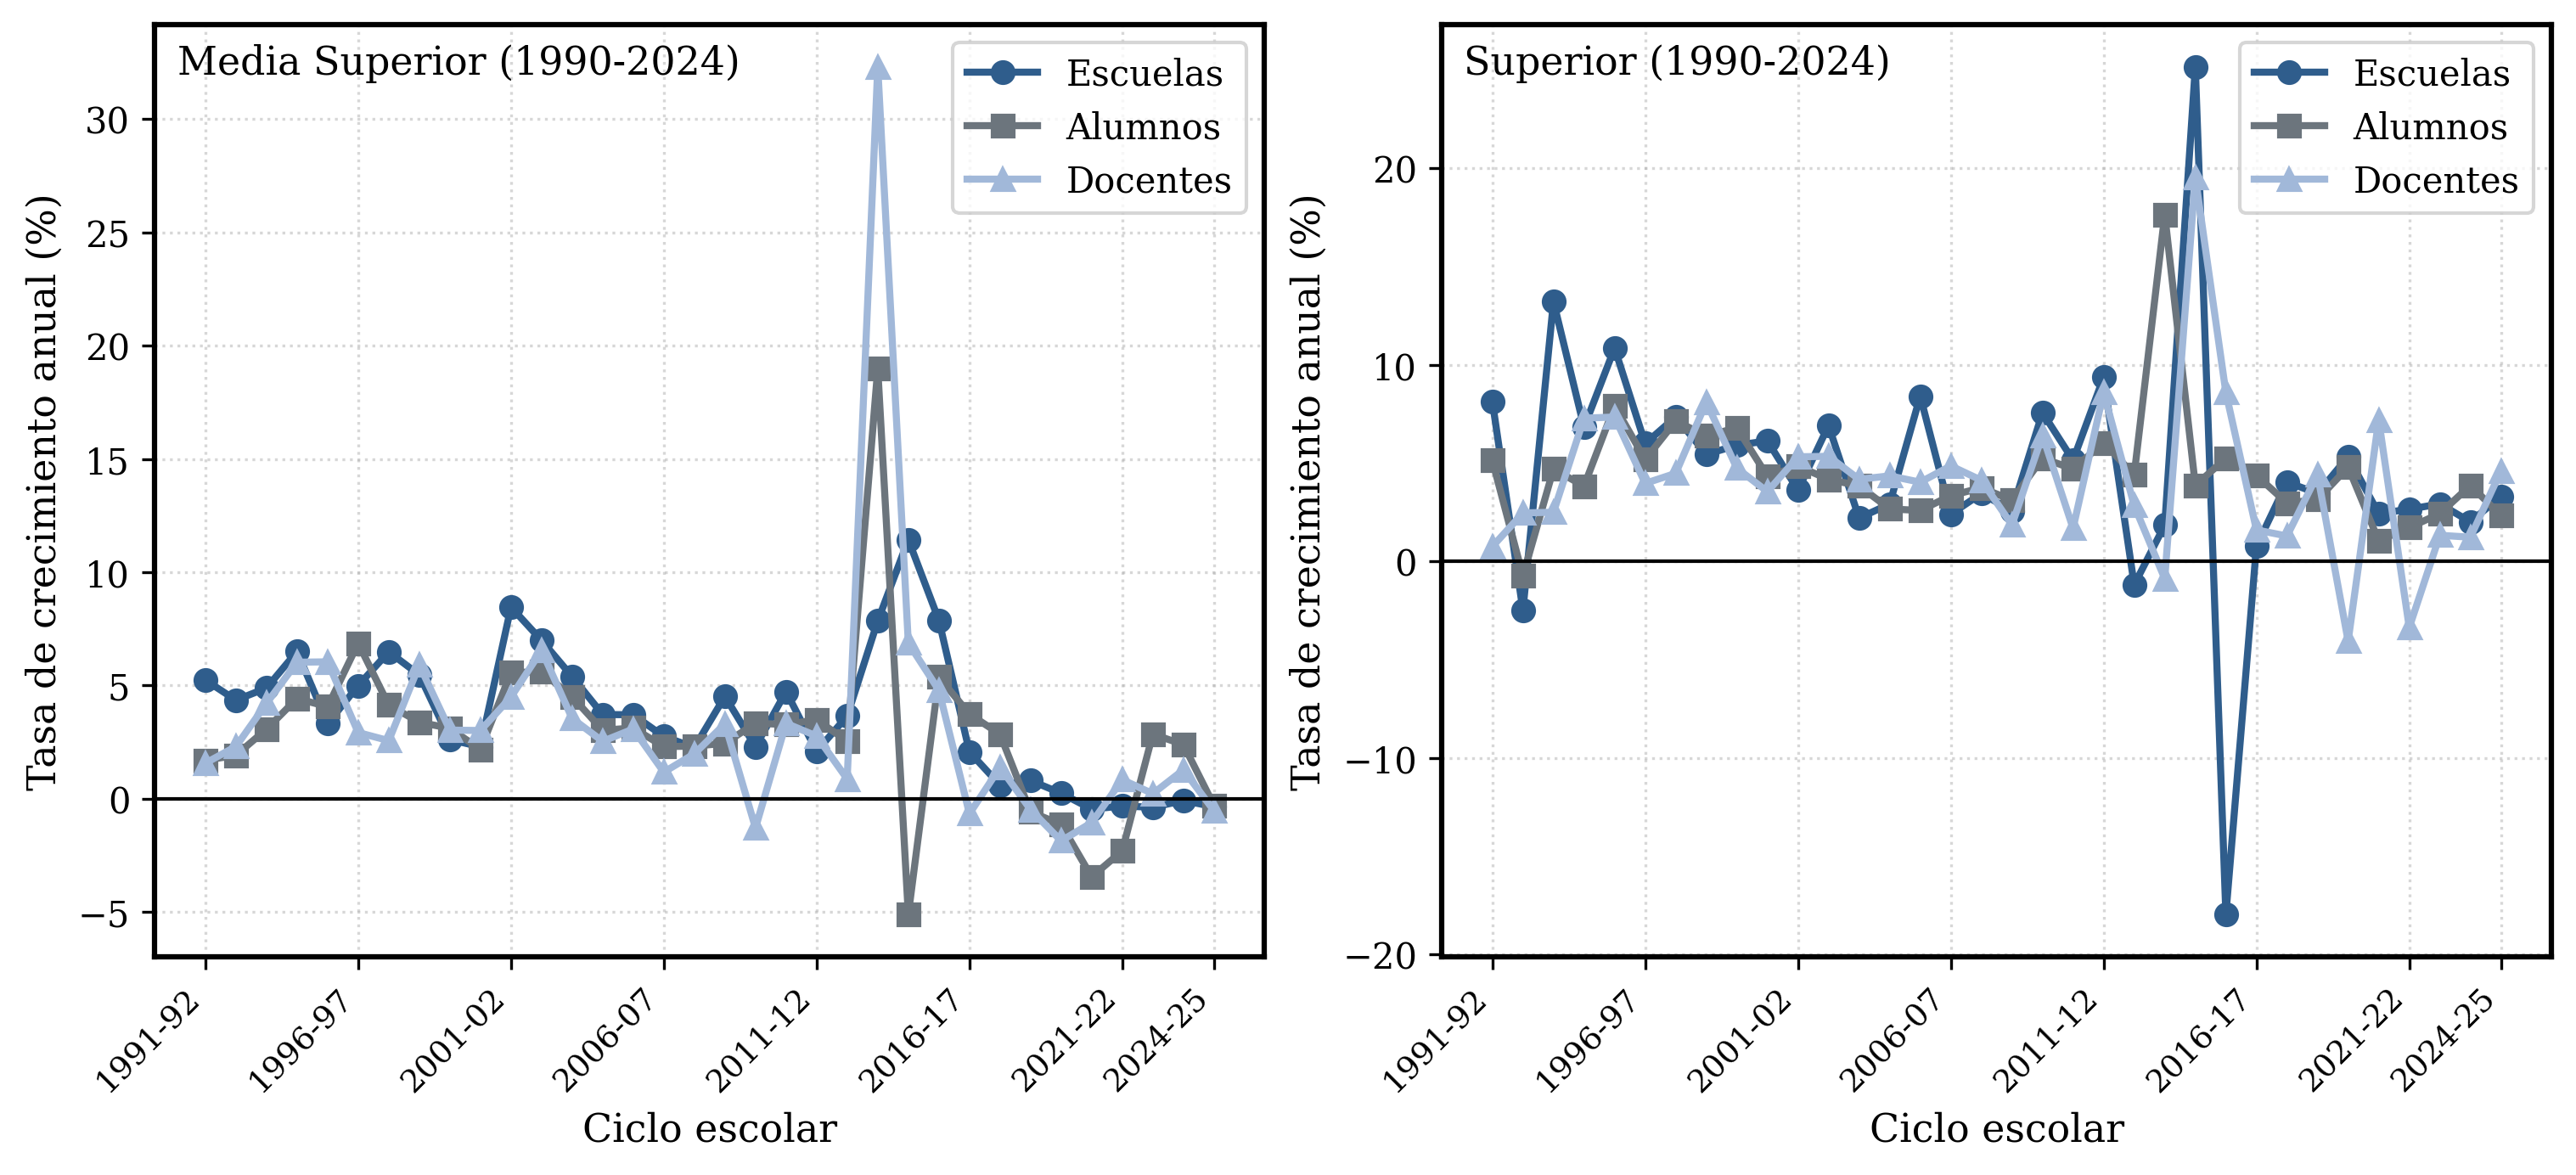

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# =====================================================
# FIGURE NUMBER
# =====================================================
FIG_NUM = '1.15'

# =====================================================
# UNIFIED ACADEMIC STYLE
# =====================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# =====================================================
# DATOS (1990‑2024)
# =====================================================
data_90_24 = {
    'Ciclo': [
        '1990-91', '1991-92', '1992-93', '1993-94', '1994-95', '1995-96', '1996-97', '1997-98', '1998-99', '1999-00',
        '2000-01', '2001-02', '2002-03', '2003-04', '2004-05', '2005-06', '2006-07', '2007-08', '2008-09', '2009-10',
        '2010-11', '2011-12', '2012-13', '2013-14', '2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20',
        '2020-21', '2021-22', '2022-23', '2023-24', '2024-25'
    ],
    'Escuelas_MS': [6222, 6548, 6833, 7167, 7633, 7886, 8280, 8817, 9299, 9542, 9761, 10587, 11327, 11938, 12382, 12841, 13194, 13493, 14103, 14427, 15110, 15427, 15990, 17245, 19217, 20731, 21160, 21288, 21460, 21512, 21414, 21346, 21266, 21249, 21175],
    'Alumnos_MS': [2100520, 2136194, 2177225, 2244134, 2343477, 2438676, 2606099, 2713897, 2805534, 2892846, 2955783, 3120475, 3295272, 3443740, 3547924, 3658754, 3742943, 3830042, 3923822, 4054709, 4187528, 4333589, 4443792, 5287418, 5017281, 5286867, 5484559, 5640841, 5608220, 5544608, 5353499, 5230594, 5379859, 5508572, 5492491],
    'Docentes_MS': [145382, 147667, 151073, 157433, 166921, 177009, 182185, 186859, 197892, 203891, 210033, 219468, 233844, 242142, 248282, 255929, 258939, 264079, 272817, 269301, 278269, 285974, 288464, 381622, 407850, 427389, 424567, 430459, 428396, 420442, 416013, 419513, 420463, 425826, 423587],
    'Escuelas_S': [2123, 2296, 2239, 2535, 2708, 3002, 3182, 3416, 3602, 3815, 4049, 4196, 4486, 4585, 4719, 5116, 5239, 5420, 5560, 5981, 6289, 6878, 6796, 6922, 8663, 7107, 7162, 7451, 7709, 8120, 8318, 8539, 8789, 8966, 9263],
    'Alumnos_S': [1252027, 1316315, 1306621, 1368027, 1420461, 1532846, 1612318, 1727484, 1837884, 1962763, 2047895, 2147075, 2236791, 2322781, 2384858, 2446726, 2528664, 2623367, 2705190, 2847376, 2981313, 3161195, 3300348, 3882625, 4032992, 4244401, 4430248, 4561792, 4705400, 4931200, 4983206, 5069111, 5192618, 5393387, 5519791],
    'Docentes_S': [134424, 135444, 138785, 142261, 152630, 163843, 170350, 177988, 192406, 201534, 208692, 219804, 231558, 241236, 251740, 261889, 274618, 285958, 291268, 309952, 315179, 342269, 352007, 348922, 417134, 452969, 460234, 466191, 486804, 467065, 500693, 483868, 490309, 496357, 519190]
}

df = pd.DataFrame(data_90_24)

# --- Tasas de crecimiento anual (%) ---
df_growth = df[['Ciclo']].copy()
cols_to_calc = ['Escuelas_MS', 'Alumnos_MS', 'Docentes_MS', 'Escuelas_S', 'Alumnos_S', 'Docentes_S']
for col in cols_to_calc:
    df_growth[col] = df[col].pct_change() * 100
df_growth = df_growth.dropna()  # eliminamos la primera fila (NaN)

# =====================================================
# FUNCIÓN PARA GRAFICAR UN SUBPLOT (con xticks cada 5 años)
# =====================================================
def plot_growth(ax, nivel, suffix):
    col_esc = f'Escuelas_{suffix}'
    col_alum = f'Alumnos_{suffix}'
    col_doc = f'Docentes_{suffix}'
    
    # Paleta armonizada con los colores base
    colors = {'Escuelas': '#2F5D8C', 'Alumnos': '#6C757D', 'Docentes': '#A1B8D9'}
    markers = {'Escuelas': 'o', 'Alumnos': 's', 'Docentes': '^'}
    
    # Graficar las tres series
    ax.plot(df_growth['Ciclo'], df_growth[col_esc],
            label='Escuelas', color=colors['Escuelas'], marker=markers['Escuelas'],
            linewidth=2, markersize=6)
    ax.plot(df_growth['Ciclo'], df_growth[col_alum],
            label='Alumnos', color=colors['Alumnos'], marker=markers['Alumnos'],
            linewidth=2, markersize=6)
    ax.plot(df_growth['Ciclo'], df_growth[col_doc],
            label='Docentes', color=colors['Docentes'], marker=markers['Docentes'],
            linewidth=2, markersize=6)
    
    # Etiqueta del nivel (sin título)
    ax.text(0.02, 0.98, nivel, transform=ax.transAxes, ha='left', va='top',
            fontsize=11, weight='normal')
    
    ax.set_ylabel('Tasa de crecimiento anual (%)', fontsize=11)
    ax.set_xlabel('Ciclo escolar', fontsize=11)
    
    # --- Ajuste de xticks: mostrar solo cada 5 años ---
    n = len(df_growth)  # número de puntos (34)
    # Seleccionamos índices cada 5 (empezando en 0)
    indices = list(range(0, n, 5))
    # Si el último índice no está incluido, lo agregamos para mostrar el final
    if indices[-1] != n-1:
        indices.append(n-1)
    labels = [df_growth['Ciclo'].iloc[i] for i in indices]
    ax.set_xticks(indices)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    
    # Rejilla en ambos ejes
    ax.grid(axis='both', linestyle=':', alpha=0.5)
    
    # Línea de referencia en cero
    ax.axhline(0, color='black', linewidth=1)
    
    # Leyenda
    ax.legend(frameon=True, loc='best', fontsize=10)
    
    # Bordes negros
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

# =====================================================
# FIGURA CON DOS SUBPLOTS (1×2)
# =====================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

plot_growth(ax1, 'Media Superior (1990-2024)', 'MS')
plot_growth(ax2, 'Superior (1990-2024)', 'S')

# =====================================================
# GUARDADO EN outputs/figures
# =====================================================
output_dir = 'outputs/figures'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'), bbox_inches='tight')

# Si se desea visualizar, descomentar:
# plt.show()

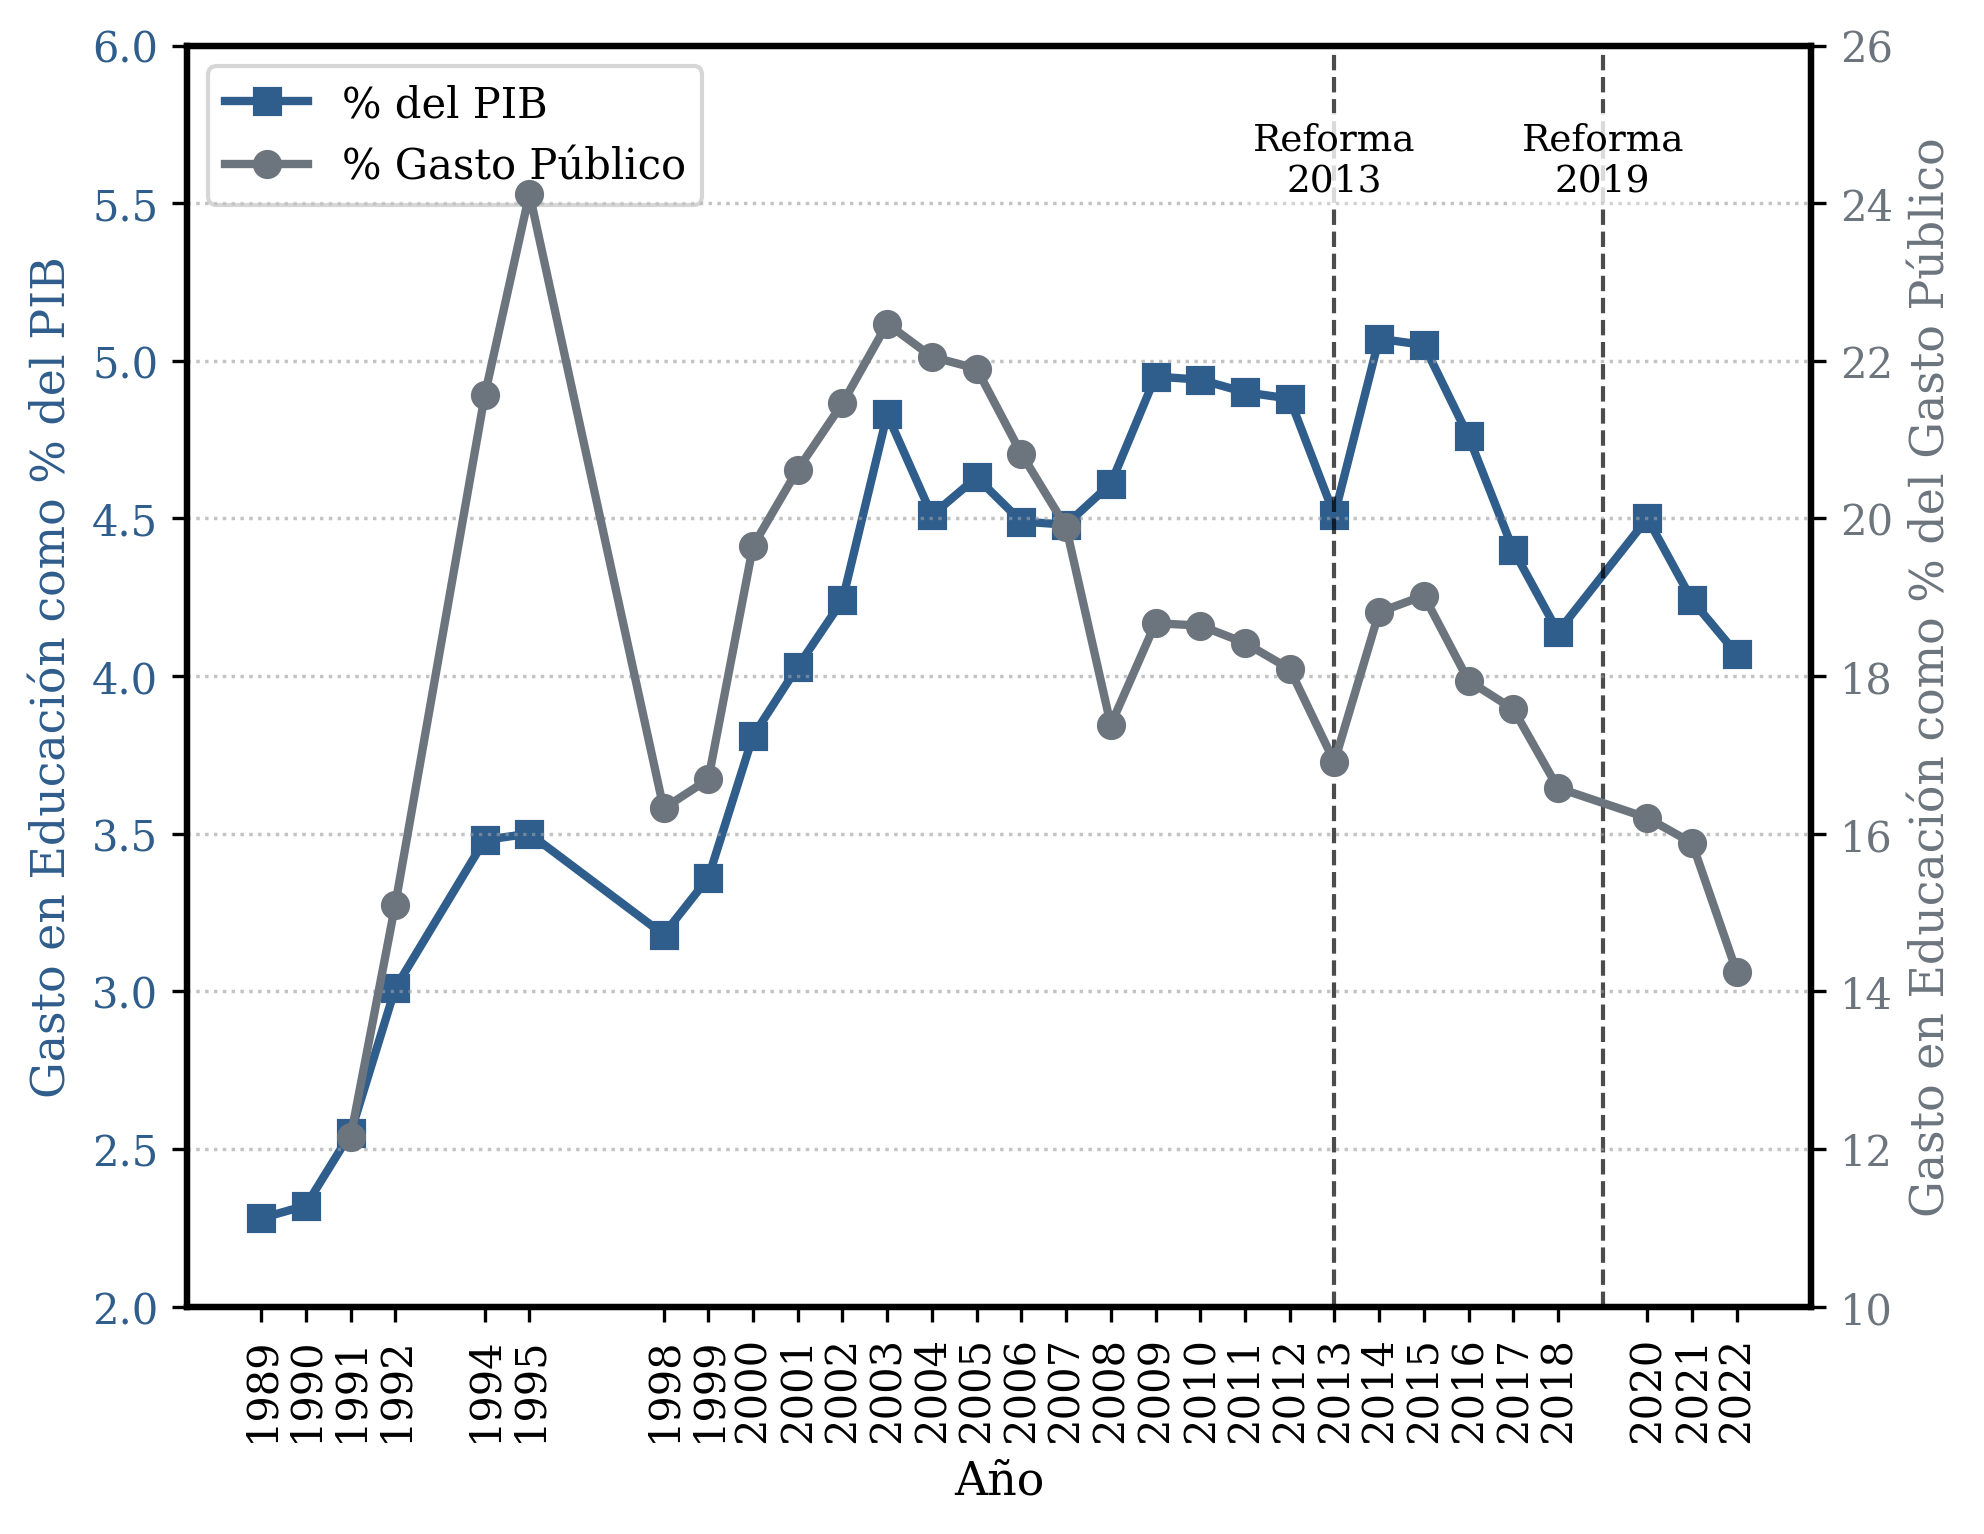

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# =====================================================
# FIGURE NUMBER
# =====================================================
FIG_NUM = '1.16'

# =====================================================
# UNIFIED ACADEMIC STYLE
# =====================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# =====================================================
# DATOS
# =====================================================
data = {
    'Year': [
        2022, 2021, 2020, 2018, 2017, 2016, 2015, 2014, 2013, 2012,
        2011, 2010, 2009, 2008, 2007, 2006, 2005, 2004, 2003, 2002,
        2001, 2000, 1999, 1998, 1995, 1994, 1992, 1991, 1990, 1989
    ],
    'Gasto_Pub': [
        14.24, 15.88, 16.20, 16.58, 17.58, 17.94, 19.02, 18.81, 16.91, 18.09,
        18.42, 18.64, 18.67, 17.38, 19.89, 20.82, 21.90, 22.05, 22.47, 21.46,
        20.62, 19.65, 16.69, 16.32, 24.12, 21.56, 15.10, 12.15, np.nan, np.nan
    ],
    'PIB': [
        4.07, 4.24, 4.50, 4.14, 4.40, 4.76, 5.05, 5.07, 4.51, 4.88,
        4.90, 4.94, 4.95, 4.61, 4.48, 4.49, 4.63, 4.51, 4.83, 4.24,
        4.03, 3.81, 3.36, 3.18, 3.50, 3.48, 3.01, 2.55, 2.32, 2.28
    ]
}

df = pd.DataFrame(data)
df = df.sort_values('Year')  # orden cronológico

# =====================================================
# FIGURA CON DOS EJES (twinx)
# =====================================================
fig, ax1 = plt.subplots(figsize=(6.5, 5), constrained_layout=True)

# Colores base de la tesis
color_pib = '#2F5D8C'      # azul oscuro
color_pub = '#6C757D'      # gris medio

# --- Eje izquierdo: % PIB ---
ax1.set_xlabel('Año', fontsize=11)
ax1.set_ylabel('Gasto en Educación como % del PIB', color=color_pib, fontsize=11)
line1 = ax1.plot(df['Year'], df['PIB'], color=color_pib, marker='s',
                 linewidth=2, markersize=6, label='% del PIB')
ax1.tick_params(axis='y', labelcolor=color_pib)
ax1.set_ylim(2, 6)

# --- Eje derecho: % Gasto Público ---
ax2 = ax1.twinx()
ax2.set_ylabel('Gasto en Educación como % del Gasto Público', color=color_pub, fontsize=11)
line2 = ax2.plot(df['Year'], df['Gasto_Pub'], color=color_pub, marker='o',
                 linewidth=2, markersize=6, label='% Gasto Público')
ax2.tick_params(axis='y', labelcolor=color_pub)
ax2.set_ylim(10, 26)

# --- Eje X: todos los años con rotación vertical (90°) ---
ax1.set_xticks(df['Year'])
ax1.set_xticklabels(df['Year'], rotation=90, ha='center', fontsize=10)

# --- Rejilla en ambos ejes Y (valores) ---
ax1.grid(axis='y', linestyle=':', alpha=0.5)
ax2.grid(axis='y', linestyle=':', alpha=0.5)

# --- Bordes negros en todos los spines ---
for spine in ax1.spines.values():
    spine.set_linewidth(1.5)
    spine.set_edgecolor('black')
for spine in ax2.spines.values():
    spine.set_linewidth(1.5)
    spine.set_edgecolor('black')

# --- Líneas verticales de reformas (2013 y 2019) ---
reformas = {2013: 'Reforma\n2013', 2019: 'Reforma\n2019'}
y_max = ax1.get_ylim()[1]  # para posicionar el texto
for anio, texto in reformas.items():
    ax1.axvline(x=anio, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax1.text(anio, y_max * 0.96, texto, ha='center', va='top', fontsize=9,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

# --- Leyenda combinada (manual) ---
from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color=color_pib, lw=2, marker='s', markersize=6),
    Line2D([0], [0], color=color_pub, lw=2, marker='o', markersize=6)
]
ax1.legend(custom_lines, ['% del PIB', '% Gasto Público'],
           frameon=True, loc='upper left', fontsize=10)

# =====================================================
# GUARDADO EN outputs/figures
# =====================================================
output_dir = 'outputs/figures'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'), bbox_inches='tight')

# Si se desea visualizar, descomentar:
# plt.show()

/var/folders/lw/wsksmjcd29scklkcylgwjjlr0000gn/T/ipykernel_53977/217818093.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(grupos_edad, fontsize=10)
/var/folders/lw/wsksmjcd29scklkcylgwjjlr0000gn/T/ipykernel_53977/217818093.py:84: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  legend_handles = [Patch(color=c, edgecolor='black') for c in colores]


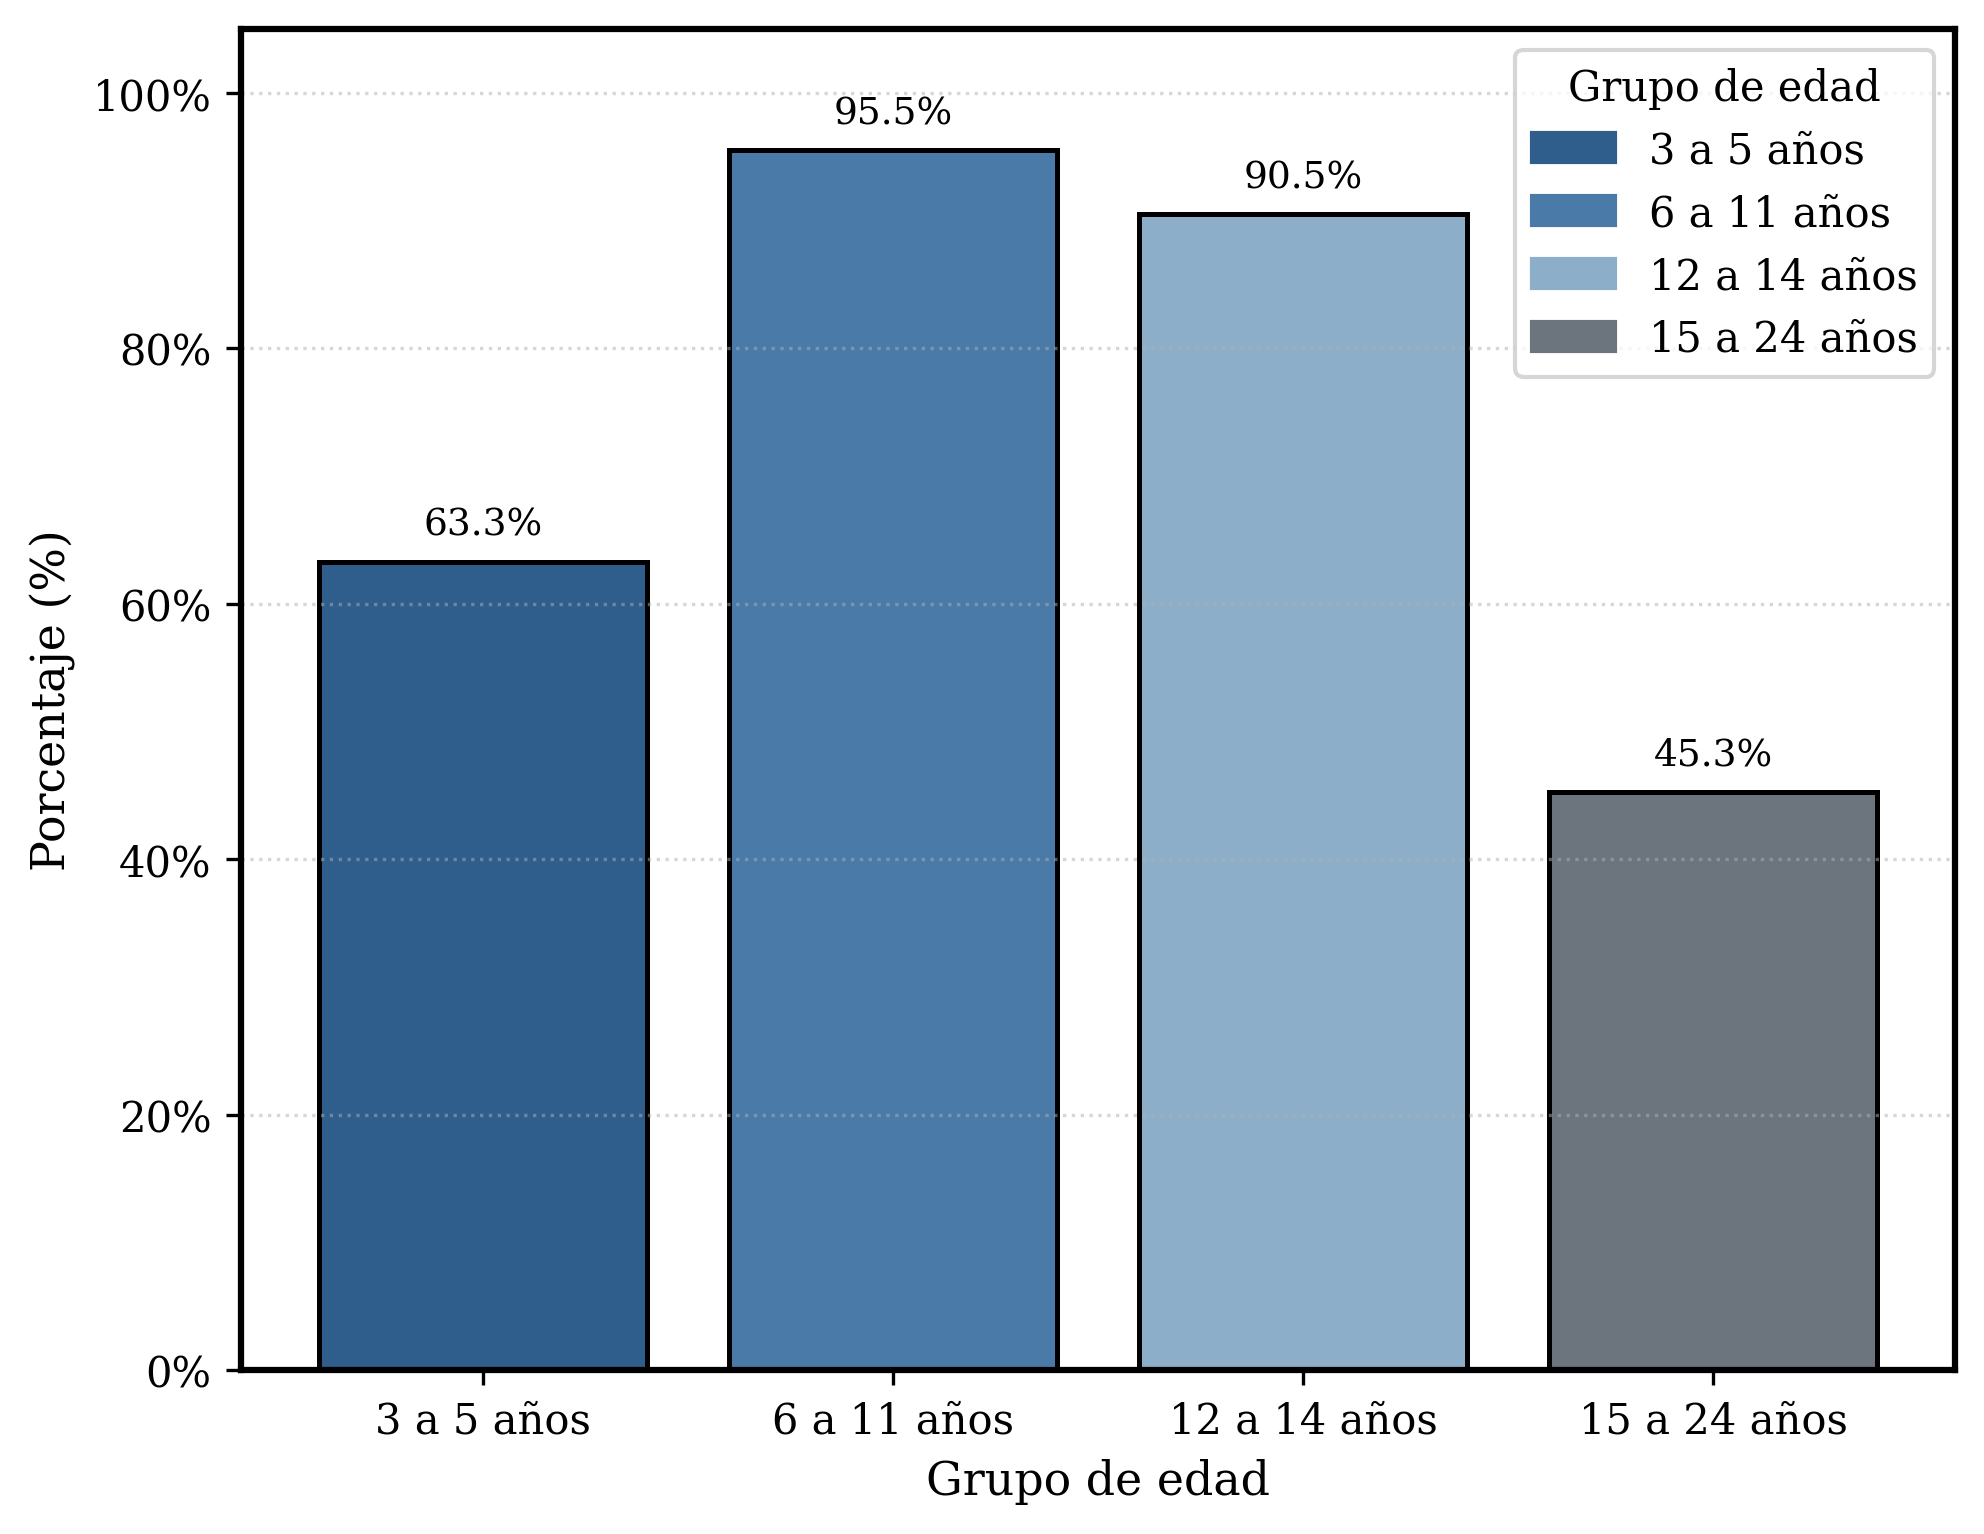

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import os

# =====================================================
# FIGURE NUMBER
# =====================================================
FIG_NUM = '1.17'

# =====================================================
# UNIFIED ACADEMIC STYLE
# =====================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# =====================================================
# DATOS
# =====================================================
grupos_edad = ["3 a 5 años", "6 a 11 años", "12 a 14 años", "15 a 24 años"]
porcentajes = [63.3, 95.5, 90.5, 45.3]

# Paleta de colores armonizada con los colores base (#2F5D8C y #6C757D)
# Usamos una secuencia que va del azul oscuro al gris
colores = ['#2F5D8C', '#4A7BA8', '#8DAEC9', '#6C757D']

# =====================================================
# CONFIGURACIÓN DE LA FIGURA
# =====================================================
fig, ax = plt.subplots(figsize=(6.5, 5), constrained_layout=True)

# Barras
bars = ax.bar(grupos_edad, porcentajes, color=colores, edgecolor='black', linewidth=1.2)

# =====================================================
# EJES Y ETIQUETAS
# =====================================================
ax.set_ylabel('Porcentaje (%)', fontsize=11)
ax.set_xlabel('Grupo de edad', fontsize=11)

# Eje Y
ax.set_ylim(0, 105)
ticks_y = np.arange(0, 101, 20)
ax.set_yticks(ticks_y)
ax.set_yticklabels([f"{t}%" for t in ticks_y], fontsize=10)

# Eje X (no se necesita rotación)
ax.set_xticklabels(grupos_edad, fontsize=10)

# Rejilla en Y
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Bordes negros en todos los spines
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_edgecolor('black')

# =====================================================
# ETIQUETAS DE VALOR SOBRE LAS BARRAS
# =====================================================
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1.5,                   # separación para que no toque la barra
        f"{height}%",
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )

# =====================================================
# LEYENDA
# =====================================================
# Crear parches con los colores y bordes negros
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, edgecolor='black') for c in colores]
ax.legend(
    legend_handles,
    grupos_edad,
    title="Grupo de edad",
    title_fontsize=10,
    frameon=True,
    loc='best',
    fontsize=10
)

# =====================================================
# GUARDADO EN outputs/figures
# =====================================================
output_dir = 'outputs/figures'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'), bbox_inches='tight')

# Si se desea visualizar, descomentar:
# plt.show()

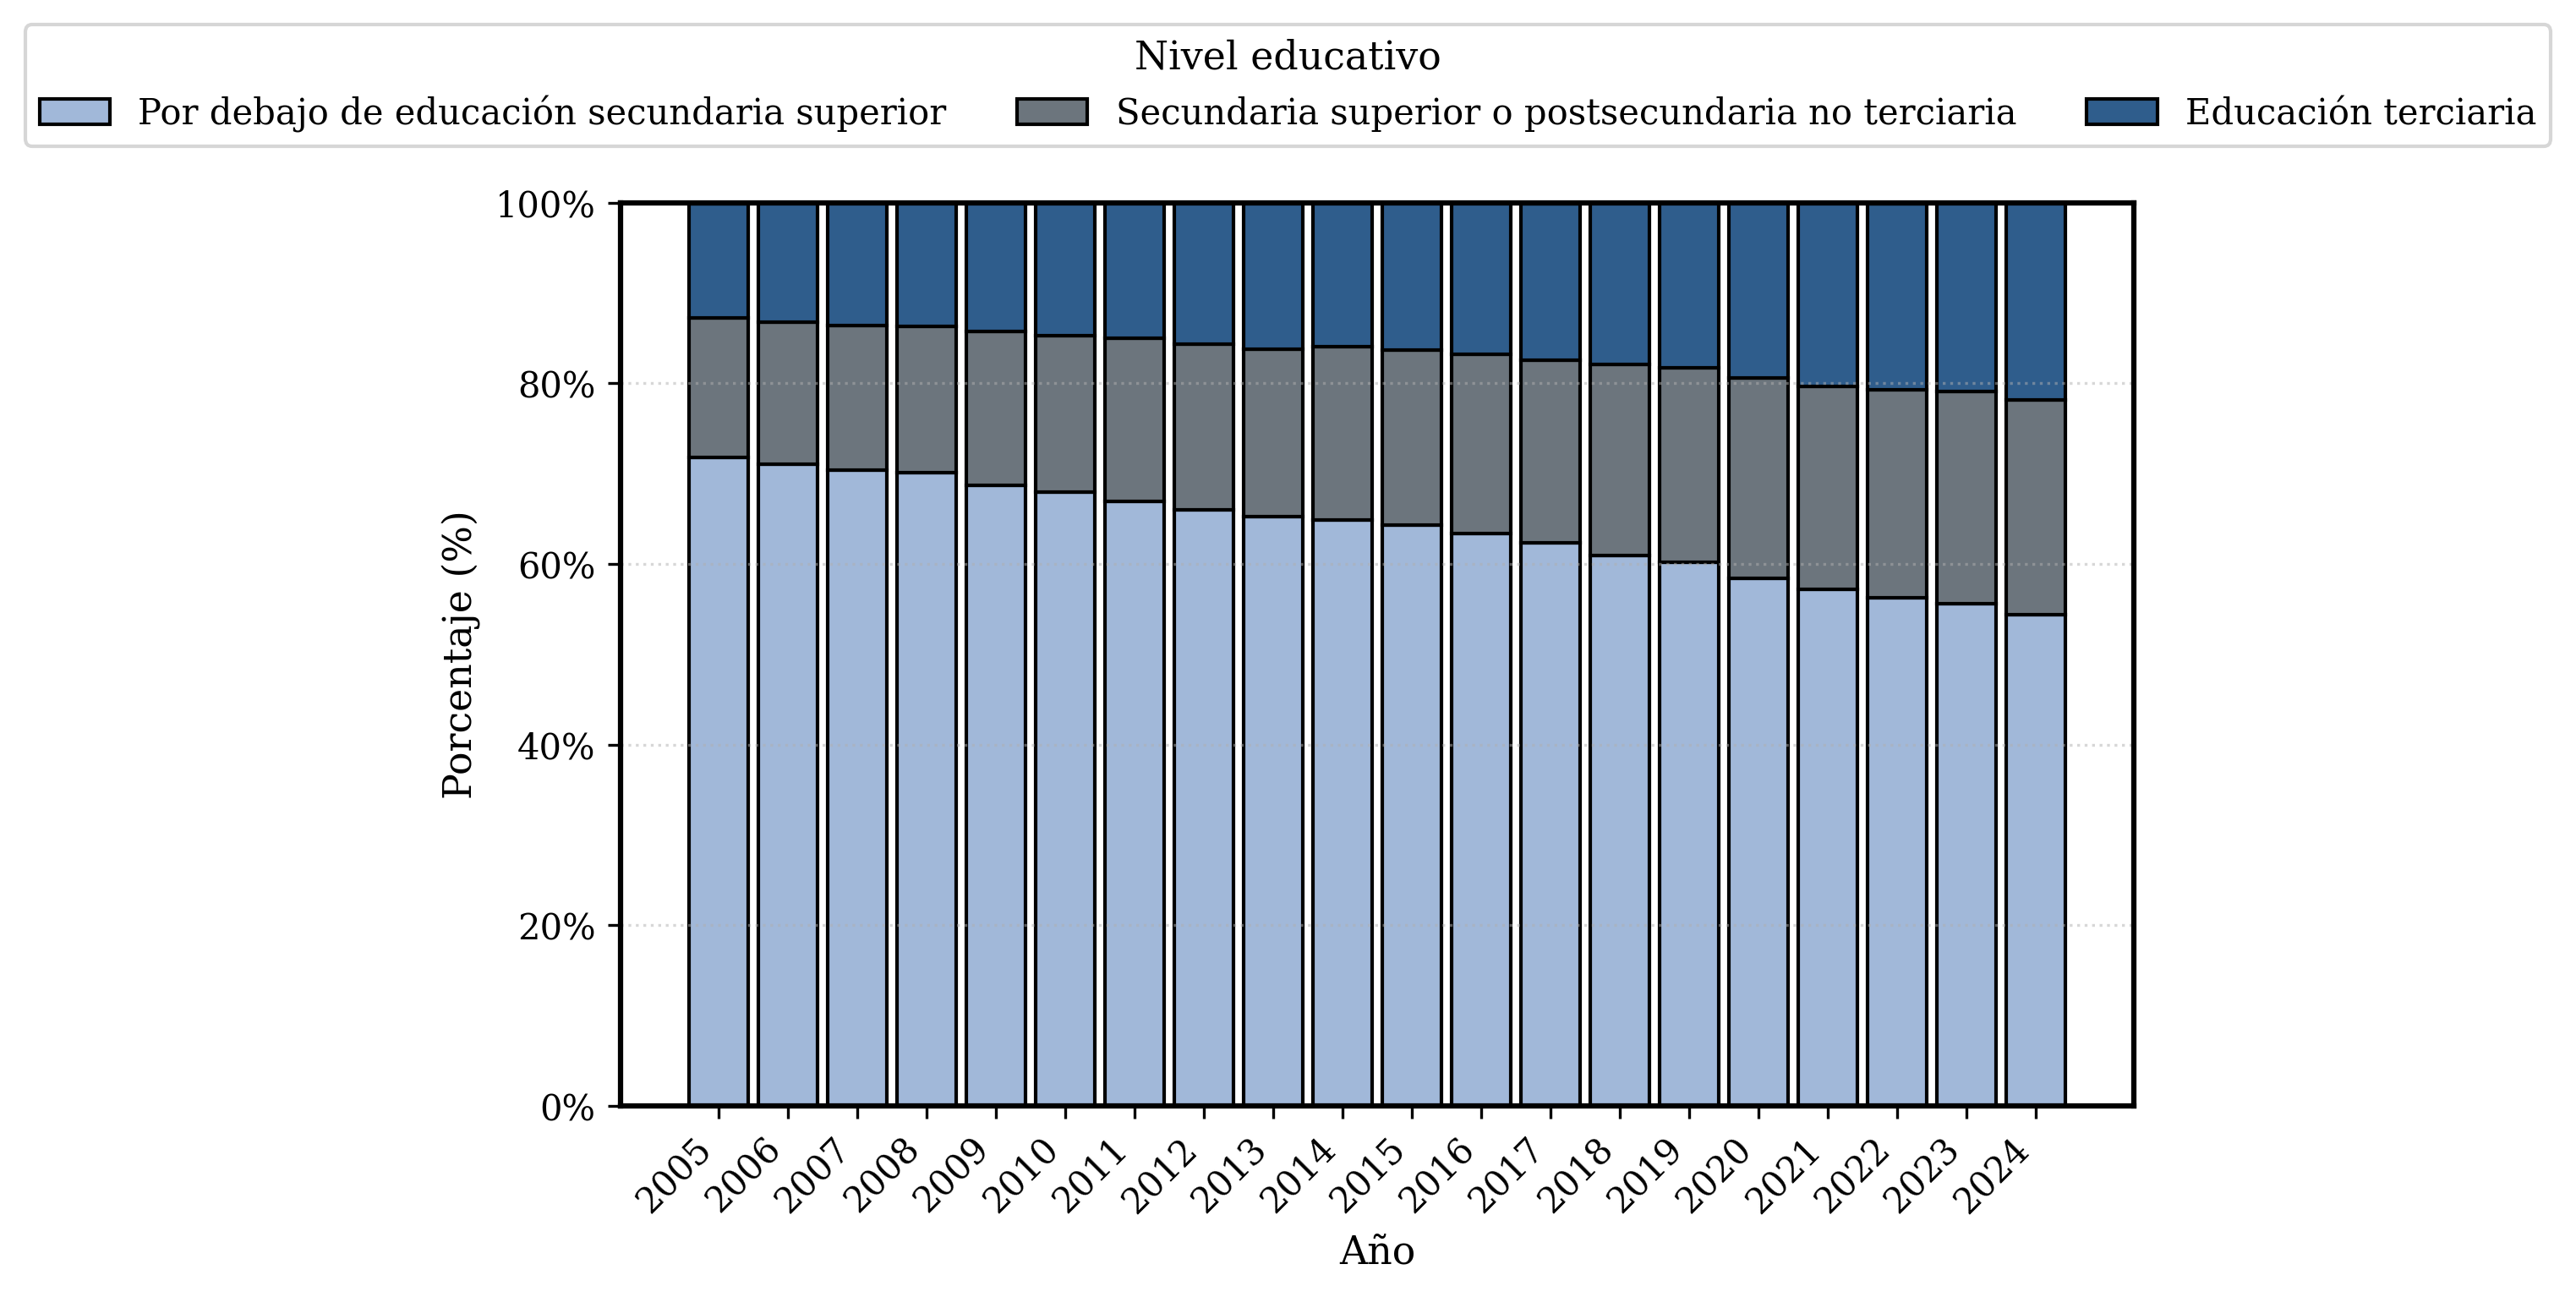

In [36]:
# =====================================================
# FIGURA 1.18 - Evolución del Nivel Educativo en México
# =====================================================
import os
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------------------
# 1. NÚMERO DE FIGURA
# -----------------------------------------------------
FIG_NUM = '1.18'

# -----------------------------------------------------
# 2. ESTILO UNIFICADO DE TESIS (tipografía, ejes, etc.)
# -----------------------------------------------------
plt.rcParams.update({
    'font.family': 'serif',          # Fuente serif (tipo Times)
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# -----------------------------------------------------
# 3. DATOS (México 2005-2024)
# -----------------------------------------------------
years = list(range(2005, 2025))

mex_below = [
    71.8, 71.0, 70.4, 70.1, 68.7, 67.9, 66.9, 66.0, 65.2, 64.9,
    64.3, 63.4, 62.3, 60.9, 60.2, 58.4, 57.2, 56.2, 55.6, 54.4
]
mex_upper = [
    15.4, 15.8, 16.0, 16.2, 17.0, 17.4, 18.1, 18.3, 18.6, 19.1,
    19.4, 19.8, 20.2, 21.2, 21.5, 22.2, 22.4, 23.1, 23.5, 23.7
]
mex_tertiary = [
    12.7, 13.3, 13.6, 13.7, 14.3, 14.7, 15.0, 15.7, 16.2, 16.0,
    16.3, 16.8, 17.4, 18.0, 18.3, 19.4, 20.5, 20.6, 21.0, 21.9
]

# -----------------------------------------------------
# 4. CONFIGURACIÓN DEL GRÁFICO (estilo del código de referencia)
# -----------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

# Paleta de colores armonizada
colors = ['#A1B8D9', '#6C757D', '#2F5D8C']   # Below, Upper, Tertiary
bar_width = 0.85

# --- Barras apiladas (sin etiquetas numéricas) ---
ax.bar(years, mex_below,
       color=colors[0],
       edgecolor='black',
       width=bar_width,
       label='Por debajo de educación secundaria superior')

ax.bar(years, mex_upper,
       bottom=mex_below,
       color=colors[1],
       edgecolor='black',
       width=bar_width,
       label='Secundaria superior o postsecundaria no terciaria')

ax.bar(years, mex_tertiary,
       bottom=np.array(mex_below) + np.array(mex_upper),
       color=colors[2],
       edgecolor='black',
       width=bar_width,
       label='Educación terciaria')

# -----------------------------------------------------
# 5. FORMATO DE EJES Y REJILLA
# -----------------------------------------------------
ax.set_ylim(0, 100)
ax.set_ylabel('Porcentaje (%)')
ax.set_yticks(np.arange(0, 101, 20))
ax.set_yticklabels([f'{i}%' for i in range(0, 101, 20)])

ax.set_xlabel('Año')
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, ha='right')

ax.grid(axis='y', linestyle=':', alpha=0.5)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# -----------------------------------------------------
# 6. LEYENDA (FUERA DEL GRÁFICO, ARRIBA CENTRADA)
# -----------------------------------------------------
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels,
    title='Nivel educativo',
    ncol=3,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.03),
    frameon=True
)

# Deja espacio arriba para la leyenda
fig.tight_layout(rect=[0, 0, 1, 0.92])

# -----------------------------------------------------
# 7. GUARDADO EN outputs/figures
# -----------------------------------------------------
output_dir = 'outputs/figures'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'),
            bbox_inches='tight')
plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'),
            bbox_inches='tight')

# plt.show()